### Importing Packages ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Reading the Training Dataset ##

In [2]:
data = pd.read_csv('ICM520_IndividualAssessment_TRAINING_DATASET.csv')
data.head(5)

,FEAT_ENV1,FEAT_ENV2,FEAT_ENV3,FEAT_ENV4,FEAT_ENV5,FEAT_ENV6,FEAT_ENV7,FEAT_ENV8,FEAT_SOC1,FEAT_SOC2,FEAT_SOC3,FEAT_SOC4,FEAT_SOC5,FEAT_GOV1,FEAT_GOV2,FEAT_GOV3,CATEGORY
0,3,0.14,1,2,8,0.22,1,2,9,0.9,0.47,-0.27,0.27,GROUP_B,2,6.0,1
1,5,0.57,1,2,1,0.58,1,4,5,0.9,0.15,-0.95,0.95,GROUP_B,5,4.0,1
2,3,0.35,1,2,4,0.03,1,3,0,0.6,0.80,-0.26,0.26,GROUP_B,10,10.0,0
3,10,0.25,1,2,6,0.04,1,1,0,0.9,0.01,-0.78,0.78,GROUP_A,0,7.0,1
4,1,0.56,1,4,8,0.00,2,2,9,0.7,0.47,-0.61,0.61,GROUP_A,6,7.0,2


#### Data Quality Checks 

In [3]:
data.shape

(2000, 17)

In [4]:
print(data.dtypes)

FEAT_ENV1      int64
FEAT_ENV2    float64
FEAT_ENV3      int64
FEAT_ENV4      int64
FEAT_ENV5      int64
FEAT_ENV6    float64
FEAT_ENV7      int64
FEAT_ENV8      int64
FEAT_SOC1      int64
FEAT_SOC2    float64
FEAT_SOC3    float64
FEAT_SOC4    float64
FEAT_SOC5    float64
FEAT_GOV1        str
FEAT_GOV2      int64
FEAT_GOV3    float64
CATEGORY       int64
dtype: object


## 1.  Checking for Missing Values

In [5]:
print(data.isna().sum())

FEAT_ENV1      0
FEAT_ENV2      0
FEAT_ENV3      0
FEAT_ENV4      0
FEAT_ENV5      0
FEAT_ENV6      0
FEAT_ENV7      0
FEAT_ENV8      0
FEAT_SOC1      0
FEAT_SOC2      0
FEAT_SOC3      0
FEAT_SOC4      0
FEAT_SOC5      0
FEAT_GOV1      0
FEAT_GOV2      0
FEAT_GOV3    184
CATEGORY       0
dtype: int64


## 2. Summary Statistics

In [6]:
## Summary statistics of the numeric columns of the dataset
print(data.describe().T)

            count       mean         std  min   25%   50%   75%     max
FEAT_ENV1  2000.0   5.030000    3.100953  0.0  2.00  5.00  8.00    10.0
FEAT_ENV2  2000.0   0.331605    0.296511  0.0  0.06  0.25  0.56     1.0
FEAT_ENV3  2000.0   0.991500    0.695464  0.0  1.00  1.00  1.00     2.0
FEAT_ENV4  2000.0   3.043500    1.201386  1.0  2.00  3.00  4.00     5.0
FEAT_ENV5  2000.0   5.002000    3.177585  0.0  2.00  5.00  8.00    10.0
FEAT_ENV6  2000.0   0.338880    0.307767  0.0  0.06  0.24  0.59     1.0
FEAT_ENV7  2000.0   0.993000    0.711480  0.0  0.00  1.00  1.00     2.0
FEAT_ENV8  2000.0   3.018500    1.243355  1.0  2.00  3.00  4.00     5.0
FEAT_SOC1  2000.0   4.960000    3.238154  0.0  2.00  5.00  8.00    10.0
FEAT_SOC2  2000.0   0.496050    0.292168  0.0  0.30  0.50  0.70     1.0
FEAT_SOC3  2000.0   0.340700    0.304010  0.0  0.06  0.26  0.58     1.0
FEAT_SOC4  2000.0  -0.331490    0.292598 -1.0 -0.55 -0.25 -0.07     0.0
FEAT_SOC5  2000.0   0.331490    0.292598  0.0  0.07  0.25  0.55 

### Dealing with feature types, misbalance and missing values

The summary statistics indicate that Social Feature 4 has negative score, the maximum value of feature Government2 is a 1000 which seems like a mistake as most of the score are of the range 0-10. Moreover, Feature Gov3 has 184 missing values. 

Ordinal Varibles: Feat_Env3, Feat_Env4, Feat_Env7, Feat_Env8, Feat_Gov1, Category
Numeric Variables: Feat_Env2, Feat_Env6. Feat_Soc2, Feat_Soc3, Feat_Soc4, Feat_Soc5

In [7]:
data['FEAT_SOC4'].value_counts()

FEAT_SOC4
 0.00    136
-0.01    108
-0.03     69
-0.02     66
-0.04     45
        ... 
-1.00      5
-0.78      4
-0.51      4
-0.86      4
-0.73      2
Name: count, Length: 101, dtype: int64

In [8]:
data["FEAT_SOC4"].describe()

count    2000.000000
mean       -0.331490
std         0.292598
min        -1.000000
25%        -0.550000
50%        -0.250000
75%        -0.070000
max         0.000000
Name: FEAT_SOC4, dtype: float64

In [9]:
data['FEAT_GOV2'].describe()

count    2000.000000
mean       38.510000
std       179.077473
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max      1000.000000
Name: FEAT_GOV2, dtype: float64

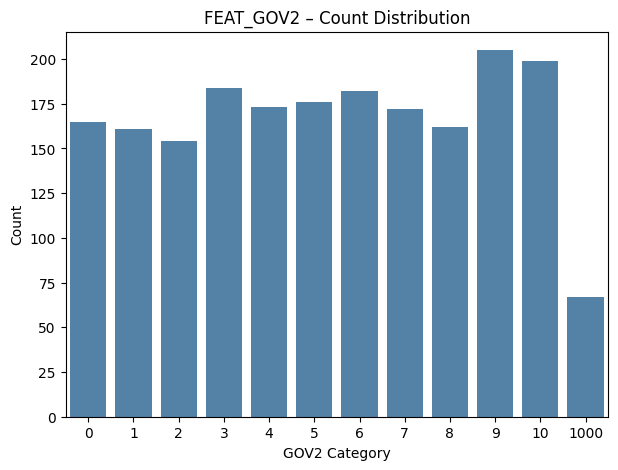

In [10]:

# Visualize the distribution of FEAT_GOV2
X = data['FEAT_GOV2']
plt.figure(figsize=(7,5))
sns.countplot(x=X, color='steelblue')
plt.title('FEAT_GOV2 – Count Distribution')
plt.xlabel('GOV2 Category')
plt.ylabel('Count')
plt.show()


In [11]:
### Unique values in each column to understand the range and distribution of the data

for col in data.columns:
    print(col, data[col].unique(), "\n")

FEAT_ENV1 [ 3  5 10  1  9  4  0  2  7  8  6] 

FEAT_ENV2 [0.14 0.57 0.35 0.25 0.56 0.02 0.75 0.66 0.21 0.73 0.03 0.51 0.92 0.86
 0.32 0.06 0.54 0.38 0.49 0.83 0.47 0.01 0.15 0.05 0.   0.1  0.04 0.18
 0.24 0.98 0.46 0.13 0.76 0.58 0.95 0.7  0.74 0.89 0.39 0.41 0.09 0.77
 0.11 0.29 0.99 0.33 0.27 0.23 0.88 0.26 0.78 0.28 0.17 0.43 0.67 0.34
 0.44 0.55 0.4  0.48 0.12 0.5  0.87 0.53 0.61 0.9  0.91 0.31 0.63 0.8
 0.72 0.79 0.08 0.85 0.16 0.37 0.68 0.22 0.84 0.93 1.   0.65 0.07 0.45
 0.81 0.52 0.82 0.69 0.19 0.2  0.42 0.59 0.3  0.36 0.71 0.62 0.64 0.6
 0.96 0.97 0.94] 

FEAT_ENV3 [1 0 2] 

FEAT_ENV4 [2 4 3 5 1] 

FEAT_ENV5 [ 8  1  4  6  3  2  5  0 10  9  7] 

FEAT_ENV6 [0.22 0.58 0.03 0.04 0.   0.97 0.06 0.21 0.29 0.12 0.09 0.2  0.89 0.65
 0.07 0.19 0.4  0.14 0.45 0.24 0.47 0.5  0.01 0.52 0.38 0.8  0.16 0.02
 0.08 0.61 0.42 0.87 0.05 0.33 0.62 0.92 0.28 0.77 0.35 0.79 0.67 0.26
 0.3  0.44 0.23 0.32 0.17 0.71 0.57 0.13 0.55 0.7  0.96 0.39 0.99 0.84
 0.15 0.43 0.75 0.46 0.78 0.9  0.94 0.95 0.1

### Data Cleaning
Firstly, cleaning Governance Features

In [12]:
## Correcting 1000 to 10 in GOV2
data['FEAT_GOV2'] = data['FEAT_GOV2'].replace(1000, 10)

In [13]:
### Taking the median of Feat_GOV3 to fill the missing values
median_gov3 = data['FEAT_GOV3'].median()
data["FEAT_GOV3"] = data["FEAT_GOV3"].fillna(median_gov3)

In [14]:
## after handling the missing values and correcting the outlier,
#       we can check the summary statistics again to see the changes
print(data["FEAT_GOV2"].describe())
print(data["FEAT_GOV3"].describe())

count    2000.000000
mean        5.345000
std         3.242411
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: FEAT_GOV2, dtype: float64
count    2000.000000
mean        4.998000
std         3.064423
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: FEAT_GOV3, dtype: float64


In [15]:
## Converting the float Gov3 into integer
data['FEAT_GOV3'] = data['FEAT_GOV3'].astype(int)


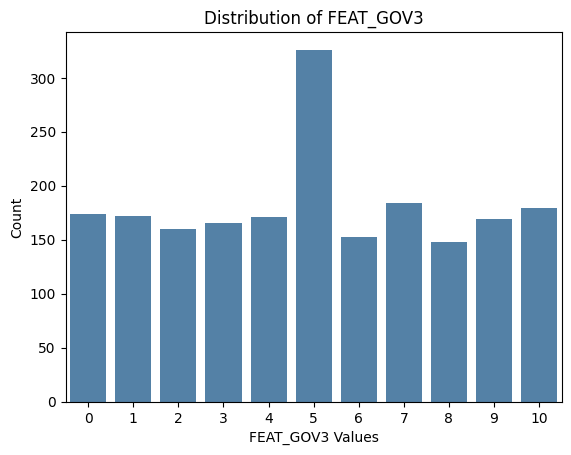

In [16]:
sns.countplot(x=data['FEAT_GOV3'], color='steelblue')
plt.title('Distribution of FEAT_GOV3')
plt.xlabel('FEAT_GOV3 Values')
plt.ylabel('Count')
plt.show()


In [17]:
print(data['FEAT_GOV1'].unique())

<StringArray>
['GROUP_B', 'GROUP_A', 'GROUP_C', 'GROUP_D']
Length: 4, dtype: str


In [18]:
## Converting Feat_GOV1 from categorical to numerical
mapping = {'GROUP_A': 0, 'GROUP_B': 1, 'GROUP_C': 2, 'GROUP_D' : 3}
data['FEAT_GOV1'] = data['FEAT_GOV1'].map(mapping)


In [19]:
data=data.copy()
data.head(5)

,FEAT_ENV1,FEAT_ENV2,FEAT_ENV3,FEAT_ENV4,FEAT_ENV5,FEAT_ENV6,FEAT_ENV7,FEAT_ENV8,FEAT_SOC1,FEAT_SOC2,FEAT_SOC3,FEAT_SOC4,FEAT_SOC5,FEAT_GOV1,FEAT_GOV2,FEAT_GOV3,CATEGORY
0,3,0.14,1,2,8,0.22,1,2,9,0.9,0.47,-0.27,0.27,1,2,6,1
1,5,0.57,1,2,1,0.58,1,4,5,0.9,0.15,-0.95,0.95,1,5,4,1
2,3,0.35,1,2,4,0.03,1,3,0,0.6,0.80,-0.26,0.26,1,10,10,0
3,10,0.25,1,2,6,0.04,1,1,0,0.9,0.01,-0.78,0.78,0,0,7,1
4,1,0.56,1,4,8,0.00,2,2,9,0.7,0.47,-0.61,0.61,0,6,7,2


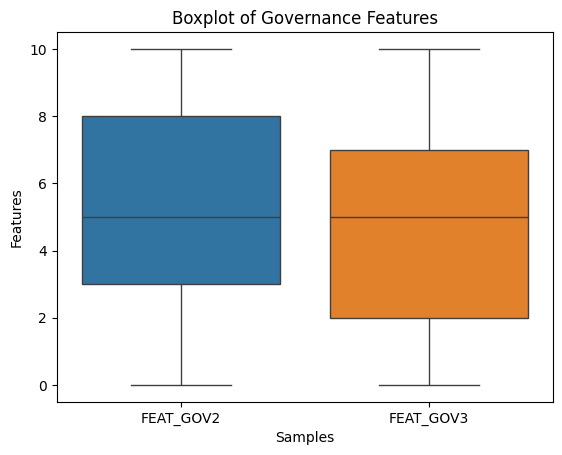

In [20]:
sns.boxplot(data=data[['FEAT_GOV2','FEAT_GOV3']])
plt.title('Boxplot of Governance Features')
plt.ylabel('Features')
plt.xlabel('Samples')
plt.show()

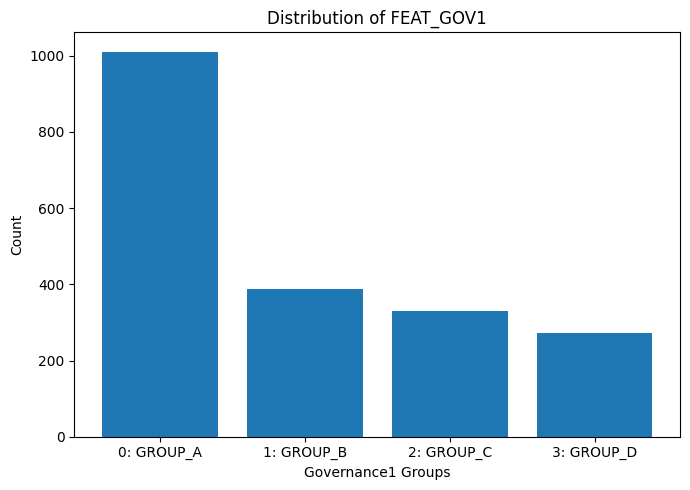

In [21]:
counts = data["FEAT_GOV1"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(counts.index, counts.values)
plt.title('Distribution of FEAT_GOV1')
plt.xlabel('Governance1 Groups')
plt.ylabel('Count')
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "0: GROUP_A",
        "1: GROUP_B",
        "2: GROUP_C",
        "3: GROUP_D"
    ]
)
plt.tight_layout()
plt.show()


### Cleaning Environmental Features
Environmental features have no missing values, we visualise to observe its distribution

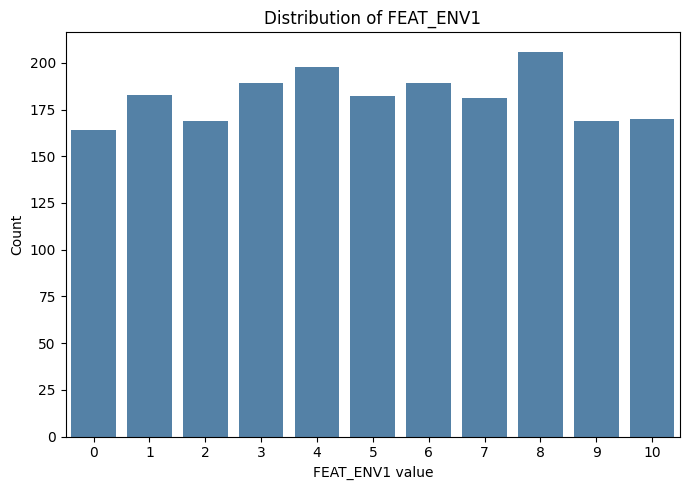

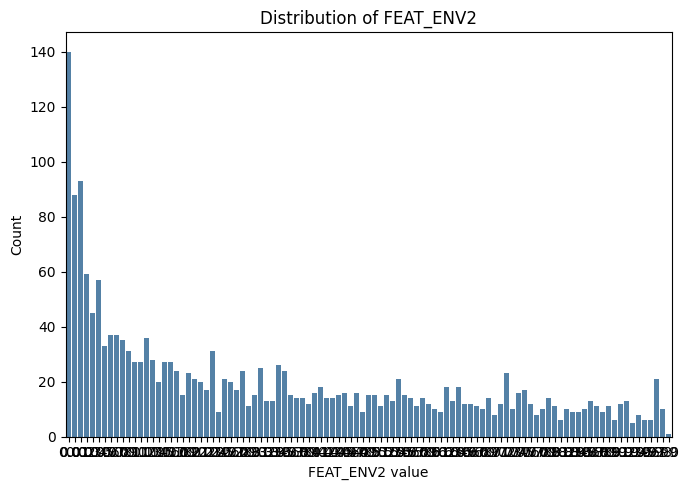

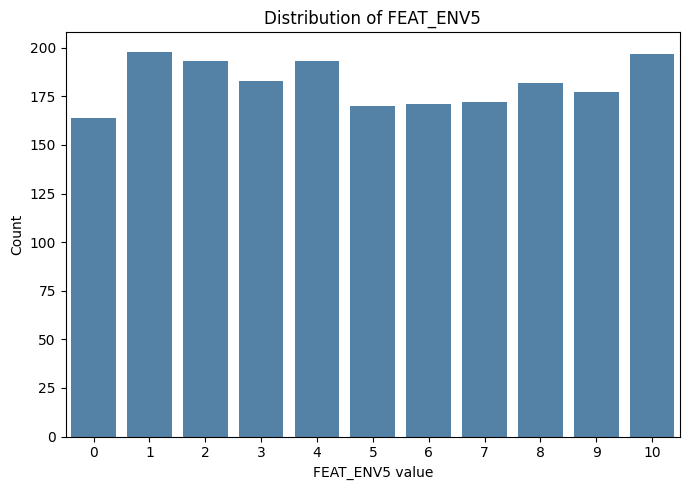

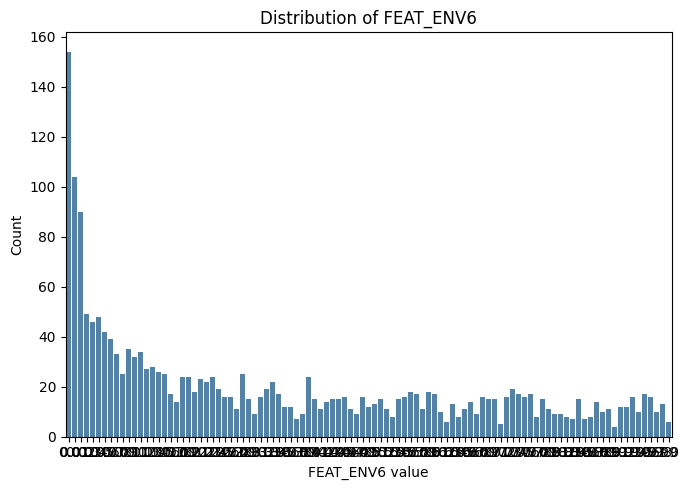

In [22]:
col = ["FEAT_ENV1", "FEAT_ENV2", "FEAT_ENV5", "FEAT_ENV6"]
for c in col:
    plt.figure(figsize=(7,5))
    sns.countplot(x=data[c], color='steelblue')
    plt.title(f'Distribution of {c}')
    plt.xlabel(f'{c} value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

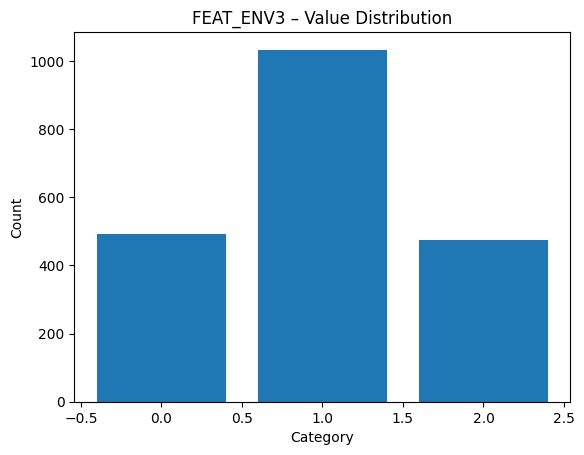

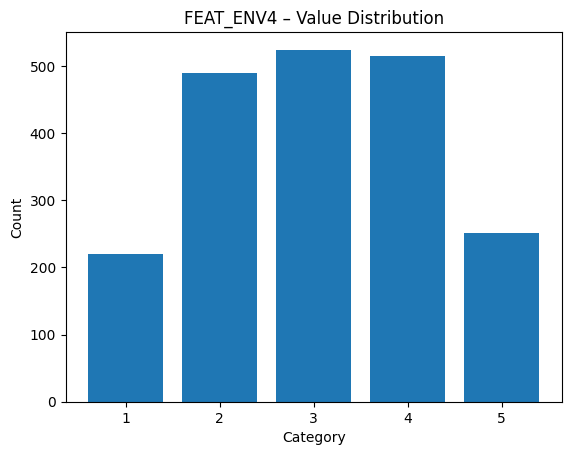

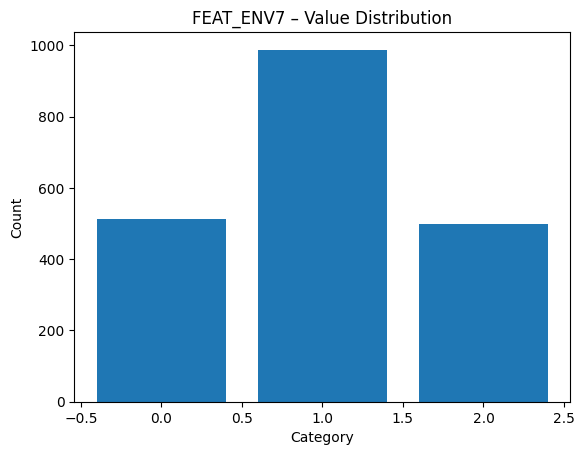

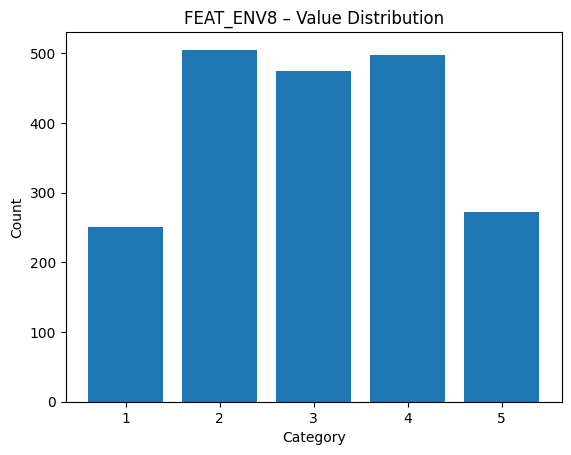

In [23]:
### Ordinal variables distribution

ordinal_vars = [
    "FEAT_ENV3",
    "FEAT_ENV4",
    "FEAT_ENV7",
    "FEAT_ENV8",
]

for var in ordinal_vars:
    count = (
        data[var]
        .value_counts().sort_index() 
    )

    plt.figure()
    plt.bar(count.index, count.values)
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.title(f"{var} – Value Distribution")
    plt.show()

### Brief summary of environmental features:
Enviornmental feature 3 and 7 have categorical distribution as such the corporations are marked as level from 0-2, and feature 4 and 8 have scoring from 1-5 which is odd as most ranges start from 0. 

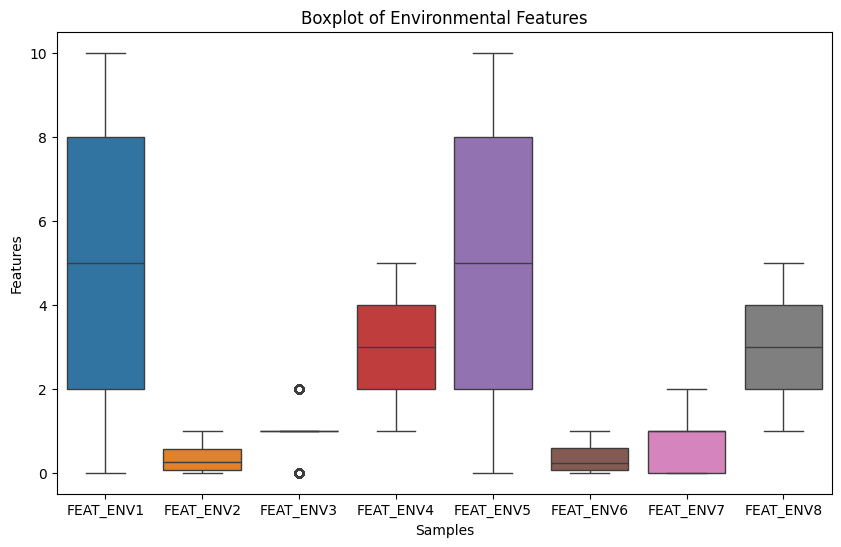

In [24]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data[['FEAT_ENV1','FEAT_ENV2','FEAT_ENV3','FEAT_ENV4','FEAT_ENV5', 'FEAT_ENV6','FEAT_ENV7','FEAT_ENV8']])
plt.title('Boxplot of Environmental Features')
plt.ylabel('Features')
plt.xlabel('Samples')
plt.show()

### Cleaning Social Features
no missing values, ploting histograms and count plots to observe distributions

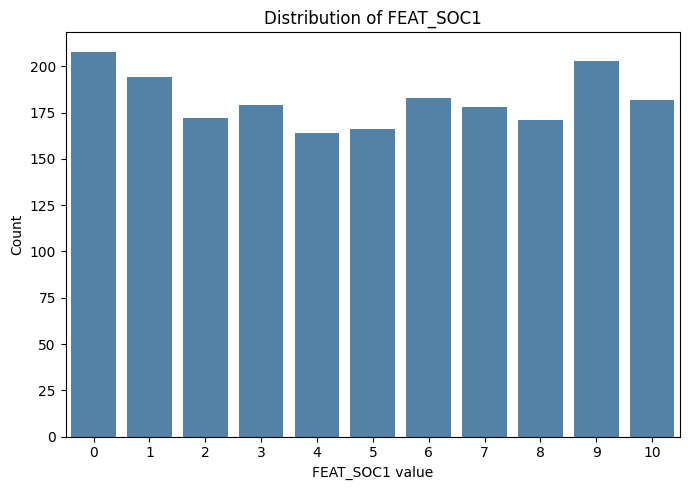

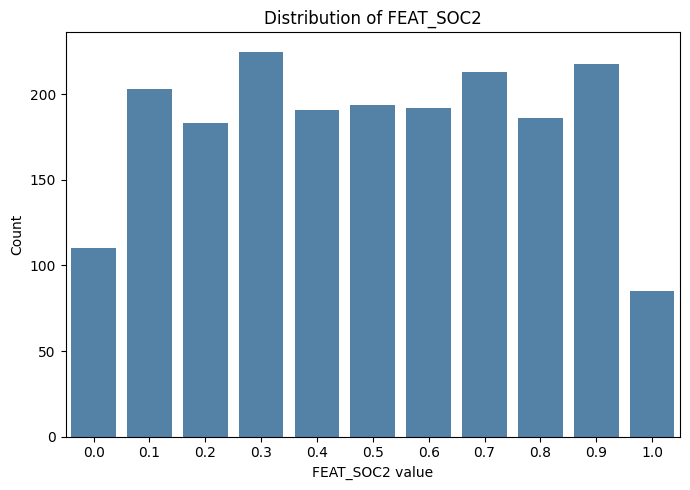

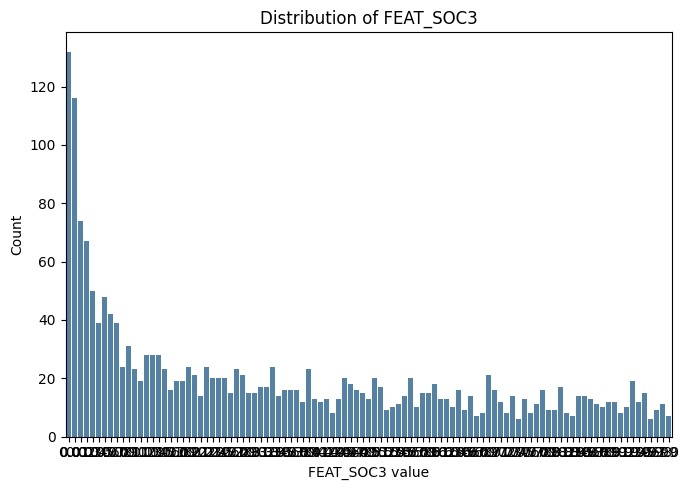

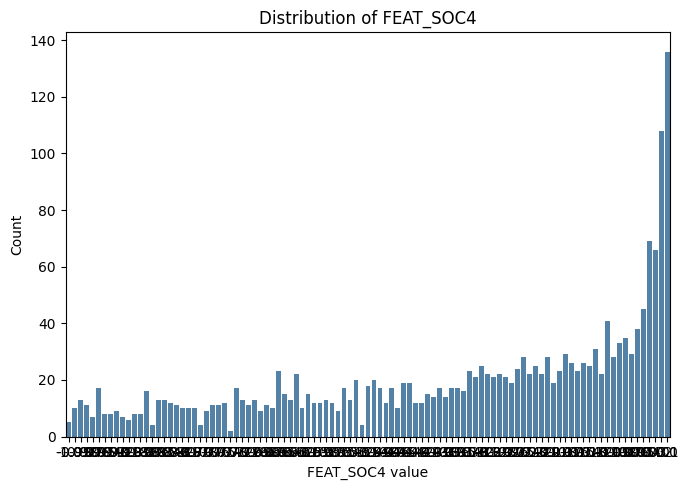

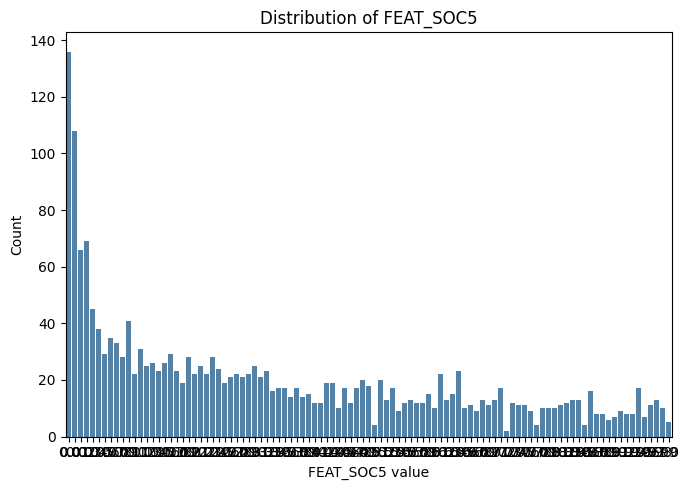

In [25]:
col = ["FEAT_SOC1", "FEAT_SOC2", "FEAT_SOC3", "FEAT_SOC4", "FEAT_SOC5"]
for c in col:
    plt.figure(figsize=(7,5))
    sns.countplot(x=data[c], color='steelblue')
    plt.title(f'Distribution of {c}')
    plt.xlabel(f'{c} value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

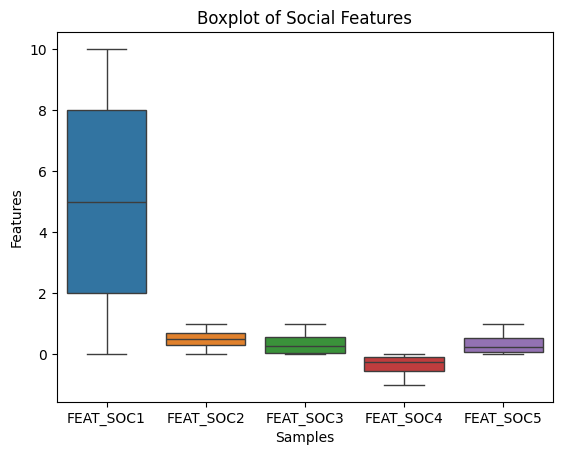

In [26]:
sns.boxplot(data=data[['FEAT_SOC1','FEAT_SOC2','FEAT_SOC3','FEAT_SOC4','FEAT_SOC5']])
plt.title('Boxplot of Social Features')
plt.ylabel('Features')
plt.xlabel('Samples')
plt.show()


## Brief summary of Social Features

Social Feature 4 is negatively skewed which doesn't seem odd as companies with bad relationship management or disproportion work-life balance in employees might arise in negative scoring. However, the rest of the scores are in range 0.0 - 0.9

### Category Variable (Target)

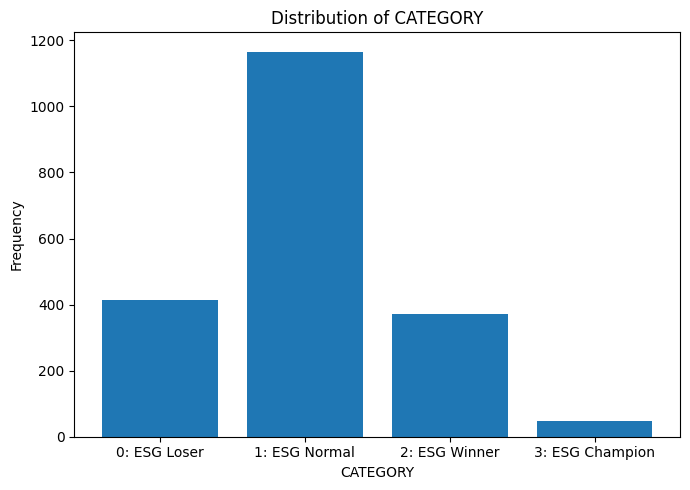

In [27]:
# Mapping the categorical target variable to numerical values for better visualization
counts = data["CATEGORY"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.bar(counts.index, counts.values)
plt.title('Distribution of CATEGORY')
plt.xlabel('CATEGORY')
plt.ylabel('Frequency')
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=[
        "0: ESG Loser",
        "1: ESG Normal",
        "2: ESG Winner",
        "3: ESG Champion"
    ]
)
plt.tight_layout()
plt.show()


After understanding the descriptive analysis of each featue, cleaning for outliear and missing values, we can classify the dataset into 3 data types first we have the ordinal features with rank levels as such 0-2, 1-5 or 0-3 etc. Second data type is the one which have a continuous score structre from 0.0 to 1.0 OR 0-10. Thirdly, we have nominal features like the Target Variable Category and Governance 1 feature which are mapped to heirarchy of levels.

Understanding the distribution of each data type will help us understand whether each feature is appropriate in model fitting. 

##  Ploting Each Features according to its Datatype

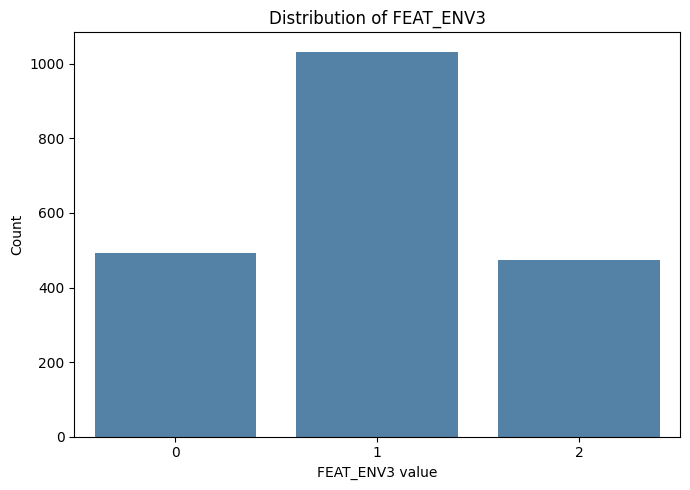

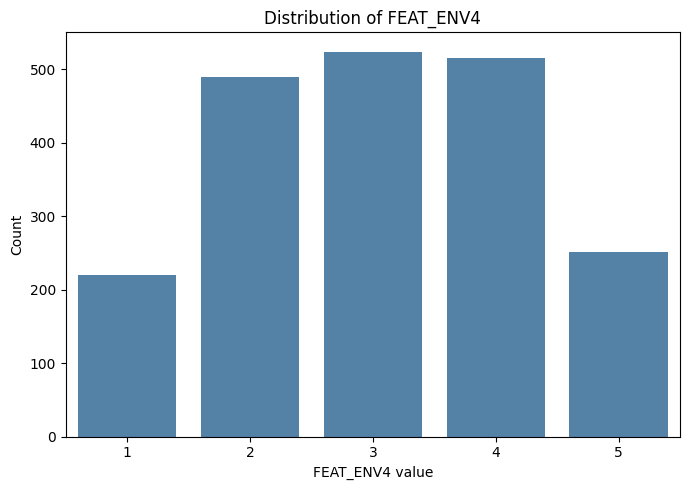

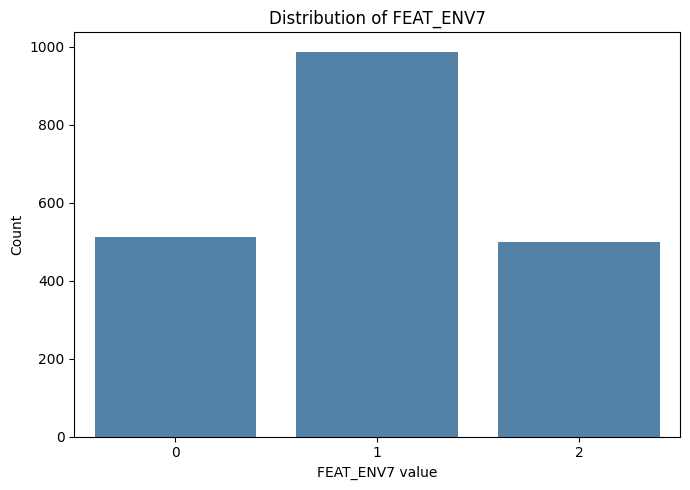

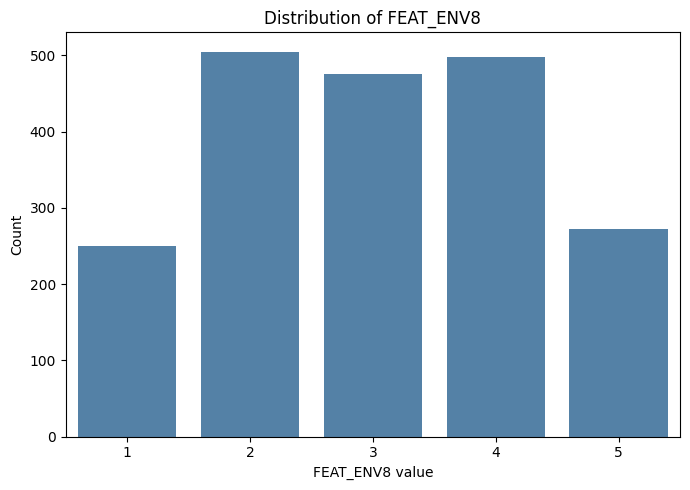

In [28]:
### Ordinal variable distribution with Ranking 
ordinal_rank = [
    "FEAT_ENV3",
    "FEAT_ENV4",
    "FEAT_ENV7",
    "FEAT_ENV8"
]
for x in ordinal_rank:
    plt.figure(figsize=(7,5))
    sns.countplot(x=data[x], color='steelblue')
    plt.title(f'Distribution of {x}')
    plt.xlabel(f'{x} value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()    

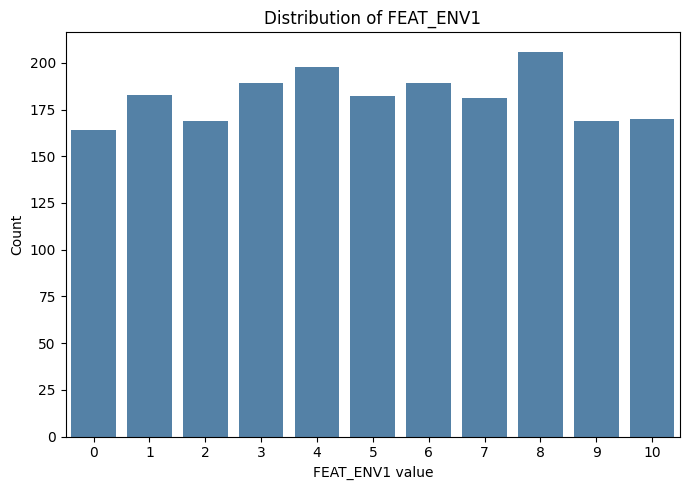

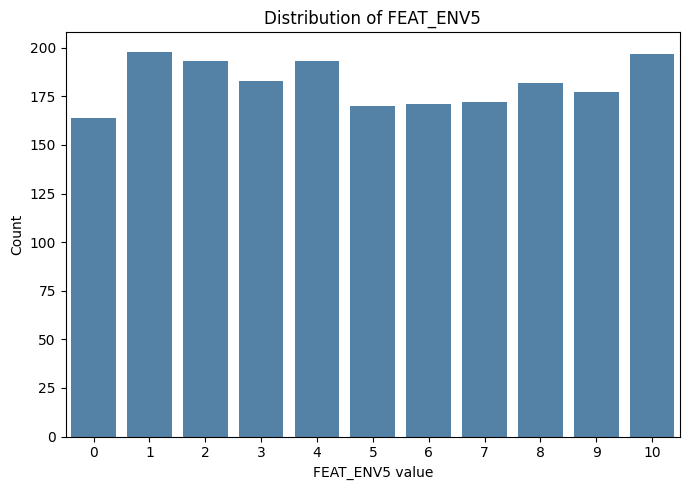

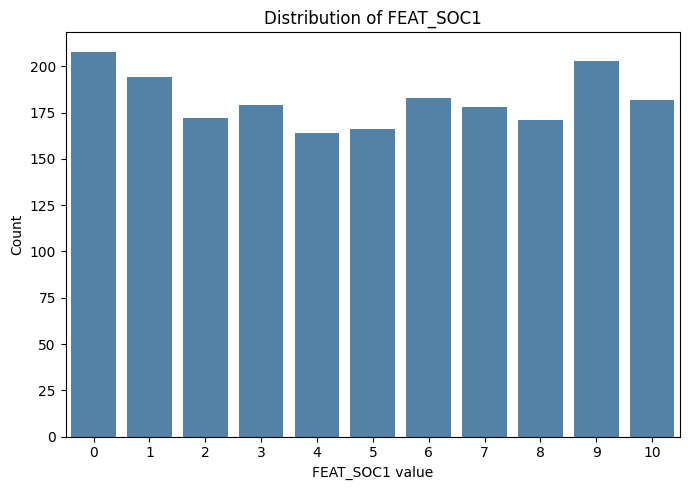

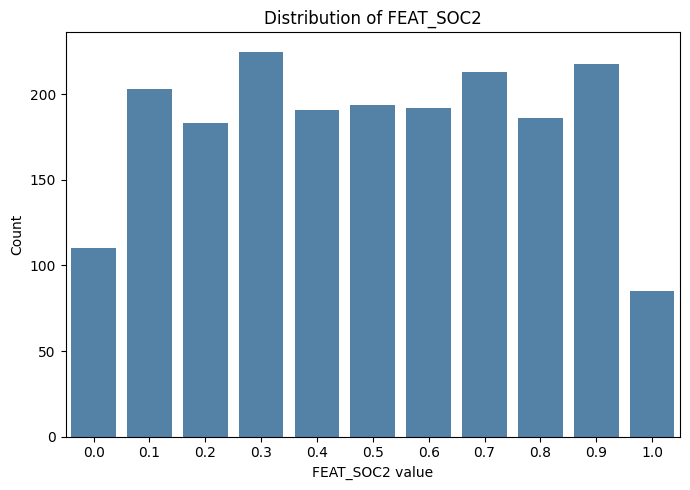

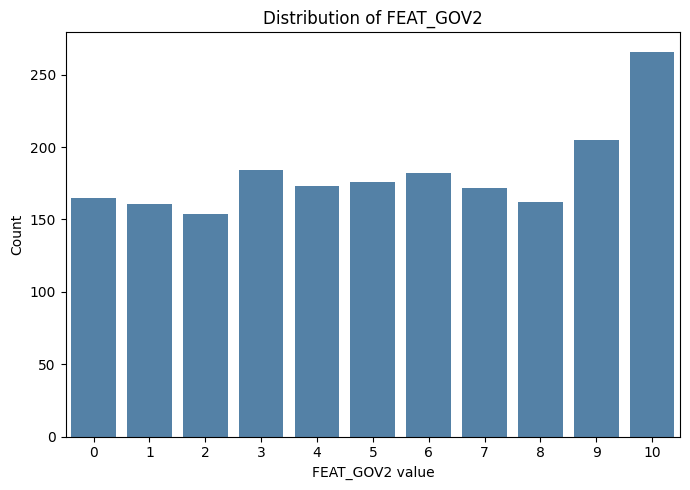

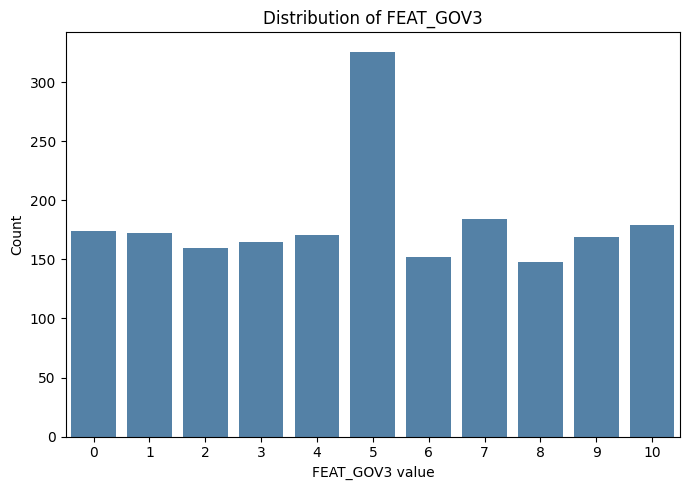

In [29]:
ordinal_score = [
    "FEAT_ENV1",
    "FEAT_ENV5",
    "FEAT_SOC1",
    "FEAT_SOC2",
    "FEAT_GOV2",
    "FEAT_GOV3"
]
for s in ordinal_score:
    plt.figure(figsize=(7,5))
    sns.countplot(x=data[s], color='steelblue')
    plt.title(f'Distribution of {s}')
    plt.xlabel(f'{s} value')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

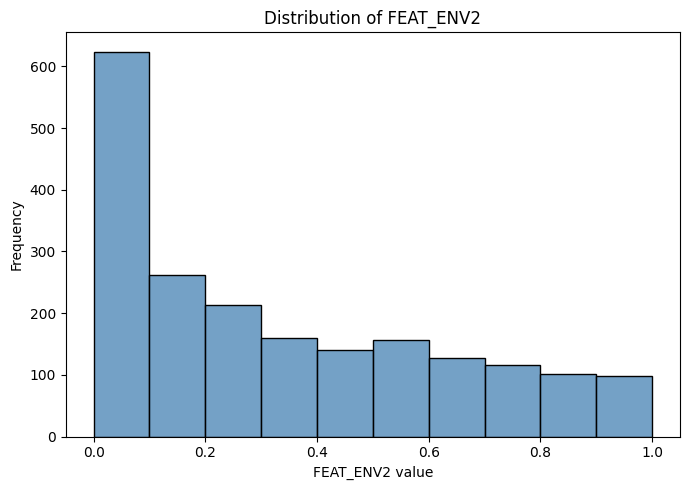

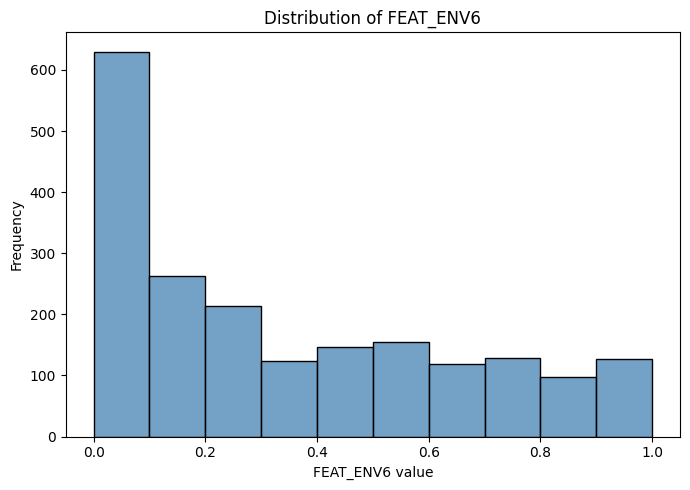

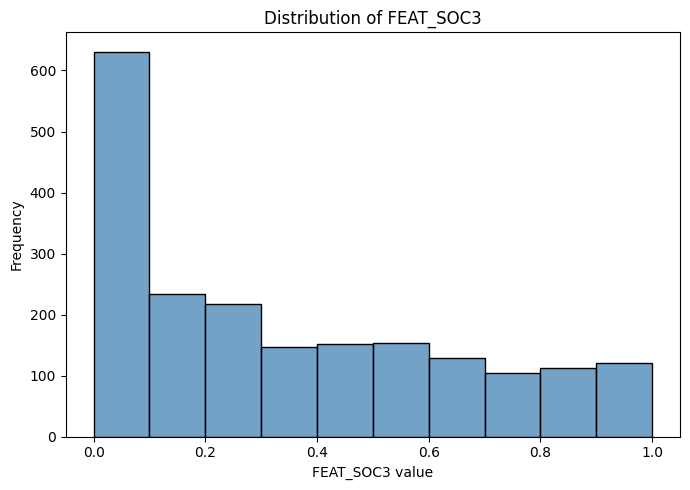

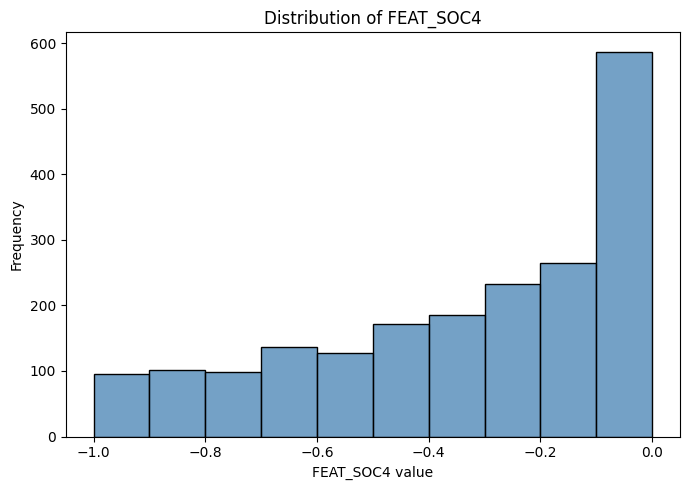

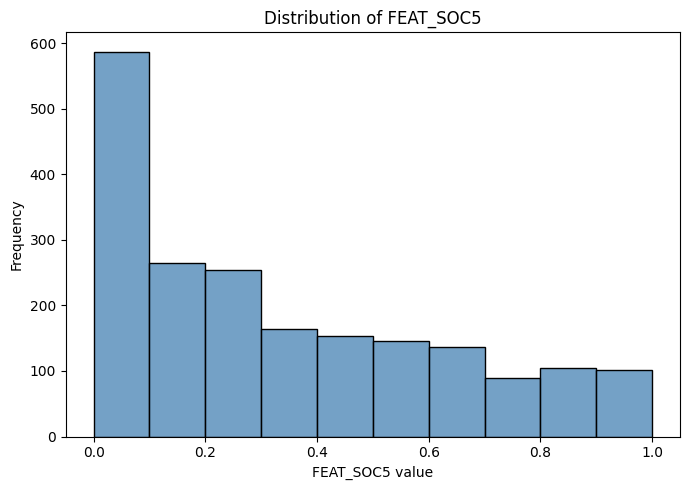

In [30]:
ordinal_score_cont=[
    "FEAT_ENV2",
    "FEAT_ENV6",
    "FEAT_SOC3",
    "FEAT_SOC4",
    "FEAT_SOC5"
]
for c in ordinal_score_cont:
    plt.figure(figsize=(7,5))
    sns.histplot(x=data[c],bins=10, color='steelblue')
    plt.title(f'Distribution of {c}')
    plt.xlabel(f'{c} value')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### Understanding any Redundant Variables

In [31]:
data['FEAT_ENV1'].describe()

count    2000.000000
mean        5.030000
std         3.100953
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: FEAT_ENV1, dtype: float64

In [32]:
data['FEAT_ENV5'].describe()


count    2000.000000
mean        5.002000
std         3.177585
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: FEAT_ENV5, dtype: float64

### Correlation Analysis

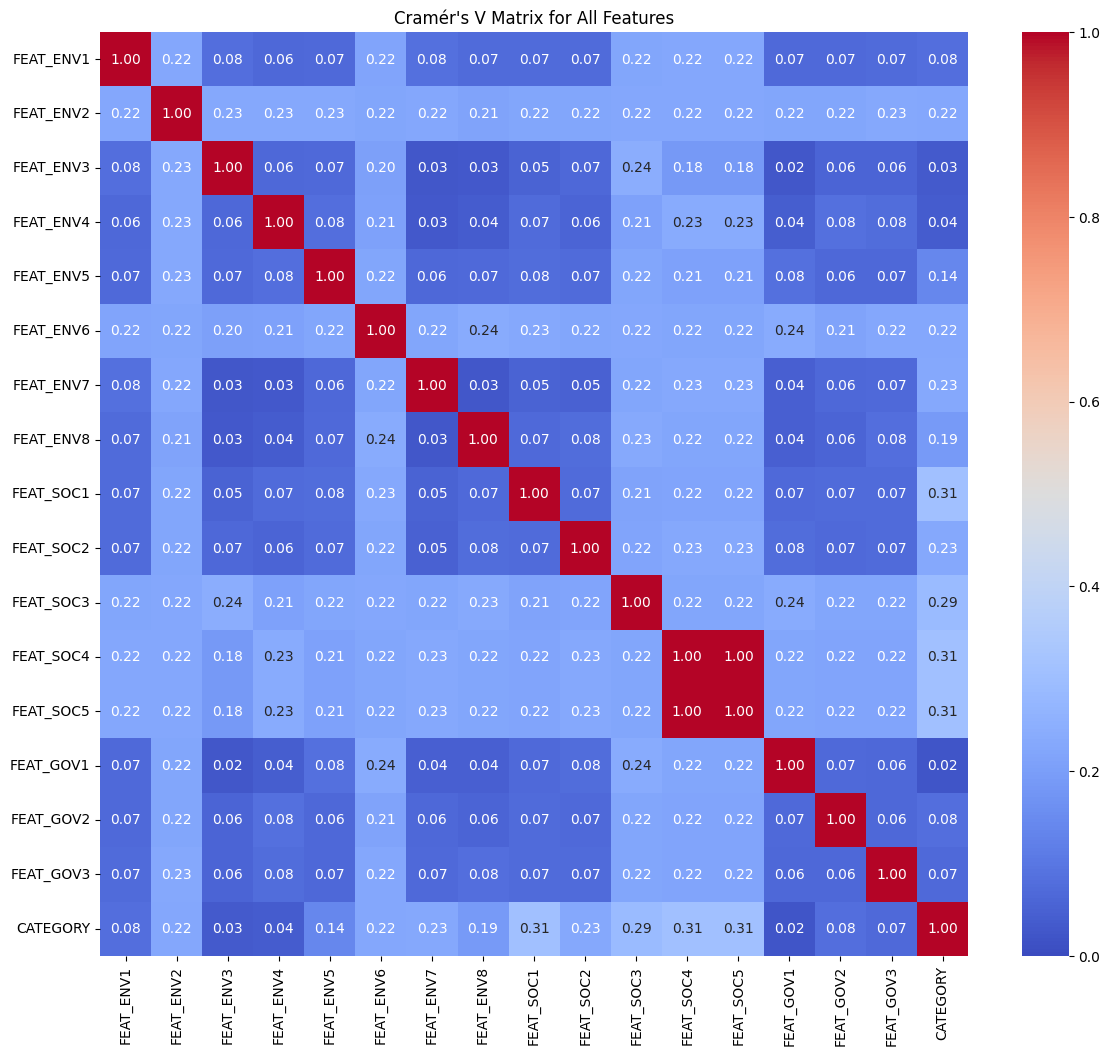

In [33]:
import scipy.stats as ss

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion, correction=False)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / n / min(k - 1, r - 1))

cols = data.columns
cramer_matrix = pd.DataFrame(
    np.zeros((len(cols), len(cols))),
    index=cols,
    columns=cols
)

for i in cols:
    for j in cols:
        cramer_matrix.loc[i, j] = cramers_v(data[i], data[j])

plt.figure(figsize=(14, 12))
sns.heatmap(cramer_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Cramér's V Matrix for All Features")
plt.show()

#### Data leakage occurs when a feature includes information that would not be available at prediction time or is directly derived from the target. The following checks help flag any features that are too strongly tied to `CATEGORY`.


###  Correlation Analysis by Feature Type

Features are categorized as follows:
- **Numeric (continuous):** FEAT_ENV2, FEAT_ENV6, FEAT_SOC3, FEAT_SOC2 FEAT_SOC4, FEAT_SOC5
- **Ordinal score (0-10 range):** FEAT_ENV1, FEAT_ENV5, FEAT_SOC1, FEAT_GOV2, FEAT_GOV3
- **Ordinal rank (categorical 0-2 or 1-5):** FEAT_ENV3, FEAT_ENV4, FEAT_ENV7, FEAT_ENV8, FEAT_GOV1

In [34]:
# Separate features by type
numeric_continuous = ["FEAT_ENV2", "FEAT_ENV6", "FEAT_SOC3" ,"FEAT_SOC4", "FEAT_SOC5"]
ordinal_score = ["FEAT_ENV1", "FEAT_ENV5", "FEAT_SOC1", "FEAT_SOC2","FEAT_GOV2", "FEAT_GOV3"]
ordinal_rank = ["FEAT_ENV3", "FEAT_ENV4", "FEAT_ENV7", "FEAT_ENV8", "FEAT_GOV1"]

# Pearson correlation for numeric & ordinal score features
all_numeric_ordinal = numeric_continuous + ordinal_score
numeric_corr_scores = data[all_numeric_ordinal].corrwith(data["CATEGORY"]).abs().sort_values(ascending=False)
print("=" * 70)
print("PEARSON CORRELATION (Numeric Continuous + Ordinal Score Features):")
print("=" * 70)
print(numeric_corr_scores)
print()

# Flag high correlations
high_numeric_corr = numeric_corr_scores[numeric_corr_scores > 0.8]
print("High correlation (> 0.8):")
print(high_numeric_corr if len(high_numeric_corr) > 0 else "None - All features safe")
print()

# Cramér's V for ordinal rank (categorical) features
print("=" * 70)
print("CRAMÉR'S V (Ordinal Rank / Categorical Features):")
print("=" * 70)
cramer_rank_scores = {col: cramers_v(data[col], data["CATEGORY"]) for col in ordinal_rank}
cramer_rank_df = pd.Series(cramer_rank_scores).sort_values(ascending=False)
print(cramer_rank_df)
print()

# Flag high associations
high_rank_cramer = cramer_rank_df[cramer_rank_df > 0.8]
print("High association (> 0.8):")
print(high_rank_cramer if len(high_rank_cramer) > 0 else "None - All features safe")
print()

# Summary
print("=" * 70)
print("LEAKAGE SUMMARY:")
print("=" * 70)
print(f"Numeric/Ordinal Score features with correlation > 0.8: {len(high_numeric_corr)}")
print(f"Ordinal Rank features with Cramér's V > 0.8: {len(high_rank_cramer)}")
print(f"Overall leakage risk: {'LOW' if (len(high_numeric_corr) == 0 and len(high_rank_cramer) == 0) else 'HIGH'}")


PEARSON CORRELATION (Numeric Continuous + Ordinal Score Features):
FEAT_SOC1    0.461368
FEAT_SOC2    0.325289
FEAT_SOC3    0.275540
FEAT_SOC4    0.275391
FEAT_SOC5    0.275391
FEAT_ENV5    0.213292
FEAT_ENV2    0.066385
FEAT_GOV3    0.045807
FEAT_ENV6    0.020658
FEAT_ENV1    0.004921
FEAT_GOV2    0.000071
dtype: float64

High correlation (> 0.8):
None - All features safe

CRAMÉR'S V (Ordinal Rank / Categorical Features):
FEAT_ENV7    0.229142
FEAT_ENV8    0.191024
FEAT_ENV4    0.038677
FEAT_ENV3    0.033139
FEAT_GOV1    0.021474
dtype: float64

High association (> 0.8):
None - All features safe

LEAKAGE SUMMARY:
Numeric/Ordinal Score features with correlation > 0.8: 0
Ordinal Rank features with Cramér's V > 0.8: 0
Overall leakage risk: LOW


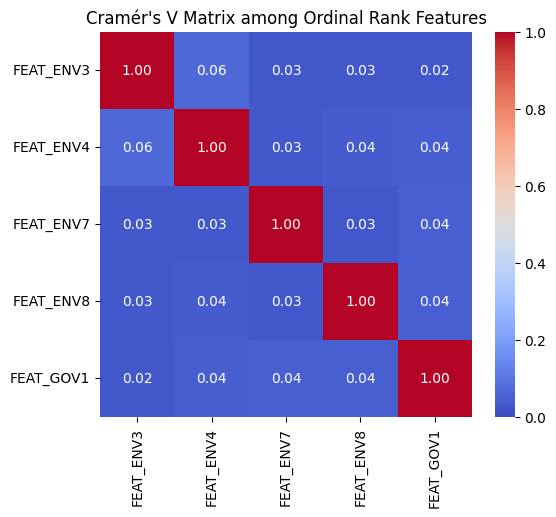

In [35]:
# Cramér's V matrix among ordinal_rank features
cols = ordinal_rank
cramer_sub = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)

for i in cols:
    for j in cols:
        cramer_sub.loc[i, j] = cramers_v(data[i], data[j])

plt.figure(figsize=(6, 5))
sns.heatmap(cramer_sub, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Cramér's V Matrix among Ordinal Rank Features")
plt.show()

           FEAT_ENV2  FEAT_ENV6  FEAT_SOC3  FEAT_SOC4  FEAT_SOC5  FEAT_ENV1  \
FEAT_ENV2   1.000000   0.024625   0.014663   0.000147  -0.000147  -0.011603   
FEAT_ENV6   0.024625   1.000000  -0.001742  -0.010283   0.010283   0.012809   
FEAT_SOC3   0.014663  -0.001742   1.000000  -0.017241   0.017241   0.021899   
FEAT_SOC4   0.000147  -0.010283  -0.017241   1.000000  -1.000000   0.022224   
FEAT_SOC5  -0.000147   0.010283   0.017241  -1.000000   1.000000  -0.022224   
FEAT_ENV1  -0.011603   0.012809   0.021899   0.022224  -0.022224   1.000000   
FEAT_ENV5   0.038326   0.021814   0.002469   0.012475  -0.012475   0.014666   
FEAT_SOC1   0.027566   0.036643   0.001695   0.027566  -0.027566  -0.013780   
FEAT_SOC2  -0.054848   0.012379   0.023663  -0.000122   0.000122   0.005321   
FEAT_GOV2   0.009258   0.011180   0.016944   0.013376  -0.013376  -0.017847   
FEAT_GOV3   0.040293  -0.004750  -0.003333   0.006251  -0.006251   0.010114   

           FEAT_ENV5  FEAT_SOC1  FEAT_SOC2  FEAT_GO

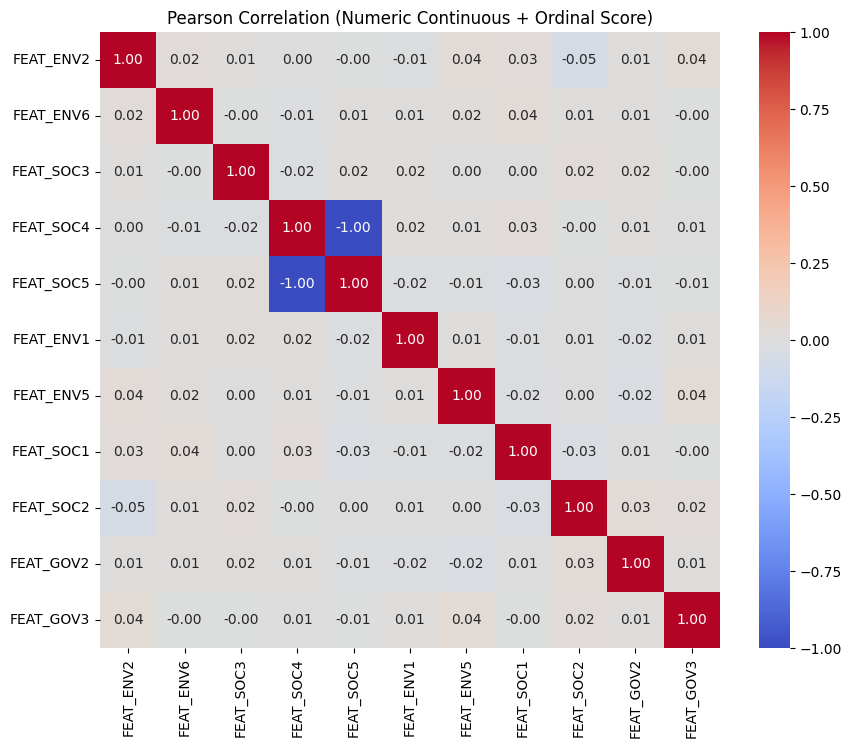

In [36]:
# Pearson correlation among numeric_continuous and ordinal_score features
# uses existing variables: data, all_numeric_ordinal, plt, sns, np

corr = data[all_numeric_ordinal].corr(method='pearson')
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson Correlation (Numeric Continuous + Ordinal Score)")
plt.show()

## Feature Selection
Overall the correlation analysis indicates, that Social features are of the highest predictive power in the Category variable, Soc4 and Soc4 high correlation makes Social Feature 4 redundant and even through some variable show similar distribution liek Env1 and Env5 their correlations are weak so we do not remove them.

In [37]:
## Droping Soc4 
data = data.drop(columns=['FEAT_SOC4'])

In [38]:
data.head(5)

,FEAT_ENV1,FEAT_ENV2,FEAT_ENV3,FEAT_ENV4,FEAT_ENV5,FEAT_ENV6,FEAT_ENV7,FEAT_ENV8,FEAT_SOC1,FEAT_SOC2,FEAT_SOC3,FEAT_SOC5,FEAT_GOV1,FEAT_GOV2,FEAT_GOV3,CATEGORY
0,3,0.14,1,2,8,0.22,1,2,9,0.9,0.47,0.27,1,2,6,1
1,5,0.57,1,2,1,0.58,1,4,5,0.9,0.15,0.95,1,5,4,1
2,3,0.35,1,2,4,0.03,1,3,0,0.6,0.80,0.26,1,10,10,0
3,10,0.25,1,2,6,0.04,1,1,0,0.9,0.01,0.78,0,0,7,1
4,1,0.56,1,4,8,0.00,2,2,9,0.7,0.47,0.61,0,6,7,2


Counts:
 CATEGORY
0     413
1    1166
2     373
3      48
Name: count, dtype: int64

Percent:
 CATEGORY
0    20.65
1    58.30
2    18.65
3     2.40
Name: count, dtype: float64


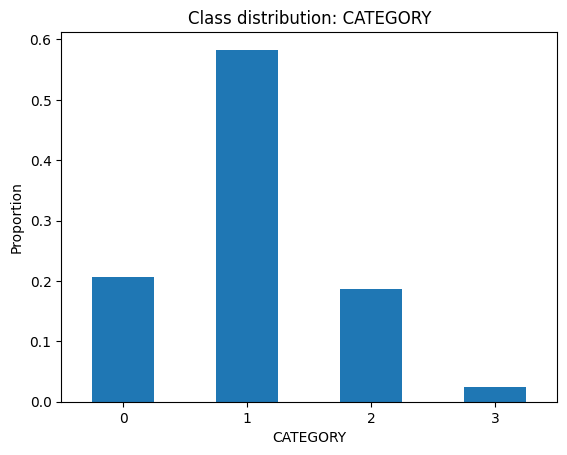

In [39]:

counts = data['CATEGORY'].value_counts().sort_index()
pct = counts / counts.sum()

print("Counts:\n", counts)
print("\nPercent:\n", (pct*100).round(2))

ax = pct.plot(kind='bar', rot=0)
ax.set_ylabel('Proportion')
ax.set_title('Class distribution: CATEGORY')
plt.show()

### Component 2 
1. Seprating X and Y in the training set
2. Doing the data-preprocessing on the test dataset
3. Scalling features of X_train and X_test
4. Fitting the model

#### 1. Spliting X and y for training test set

In [40]:
## Firstly, separating the X and Y in the training dataset for the model building and evaluation

X_train = data.drop('CATEGORY', axis=1)
y_train = data['CATEGORY']

#### 2. Test Dataset processing

In [41]:
test = pd.read_csv('ICM520_IndividualAssessment_TEST_DATASET.csv')

In [42]:
print(test.describe().T)

            count       mean         std  min     25%   50%   75%     max
FEAT_ENV1  1000.0   4.999000    3.131582  0.0  2.0000  5.00  8.00    10.0
FEAT_ENV2  1000.0   0.327710    0.293570  0.0  0.0600  0.25  0.55     1.0
FEAT_ENV3  1000.0   0.999000    0.716598  0.0  0.0000  1.00  2.00     2.0
FEAT_ENV4  1000.0   2.991000    1.209290  1.0  2.0000  3.00  4.00     5.0
FEAT_ENV5  1000.0   5.068000    3.102741  0.0  2.0000  5.00  8.00    10.0
FEAT_ENV6  1000.0   0.318900    0.286854  0.0  0.0675  0.24  0.53     1.0
FEAT_ENV7  1000.0   1.009000    0.695271  0.0  1.0000  1.00  1.00     2.0
FEAT_ENV8  1000.0   3.001000    1.237146  1.0  2.0000  3.00  4.00     5.0
FEAT_SOC1  1000.0   4.932000    3.182374  0.0  2.0000  5.00  8.00    10.0
FEAT_SOC2  1000.0   0.499900    0.297588  0.0  0.2000  0.50  0.80     1.0
FEAT_SOC3  1000.0   0.328440    0.295873  0.0  0.0600  0.25  0.55     1.0
FEAT_SOC4  1000.0  -0.337990    0.304292 -1.0 -0.5800 -0.25 -0.06     0.0
FEAT_SOC5  1000.0   0.337990    0.3042

In [43]:
## Correcting 1000 to 10 in GOV2
test['FEAT_GOV2'] = test['FEAT_GOV2'].replace(1000, 10)

In [44]:
### Taking the median of Feat_GOV3 to fill the missing values
median_gov3 = test['FEAT_GOV3'].median()
test["FEAT_GOV3"] = test["FEAT_GOV3"].fillna(median_gov3)

In [45]:
test['FEAT_GOV3'] = test['FEAT_GOV3'].astype(int)


In [46]:
## Converting Feat_GOV1 from categorical to numerical
mapping = {'GROUP_A': 0, 'GROUP_B': 1, 'GROUP_C': 2, 'GROUP_D' : 3}
test['FEAT_GOV1'] = test['FEAT_GOV1'].map(mapping)


In [47]:
## Dropping Social Feature 4 
test=test.drop(columns=['FEAT_SOC4'])

In [48]:
test.head(5)

,FEAT_ENV1,FEAT_ENV2,FEAT_ENV3,FEAT_ENV4,FEAT_ENV5,FEAT_ENV6,FEAT_ENV7,FEAT_ENV8,FEAT_SOC1,FEAT_SOC2,FEAT_SOC3,FEAT_SOC5,FEAT_GOV1,FEAT_GOV2,FEAT_GOV3,CATEGORY
0,6,0.99,0,3,10,0.11,2,3,9,0.3,0.06,0.58,3,7,1,2
1,9,0.05,2,2,8,0.88,1,5,7,0.2,0.58,0.14,0,2,6,1
2,9,0.99,1,2,2,0.00,1,1,10,0.4,0.55,0.98,0,2,3,3
3,5,0.06,1,4,1,0.79,1,3,8,0.0,0.02,0.98,0,5,9,1
4,7,0.41,1,3,9,0.59,2,5,1,0.9,0.01,0.61,0,9,4,0


##### 2. Seprating X_test and y_test

In [49]:
X_test = test.drop('CATEGORY', axis=1)
y_test = test['CATEGORY']

#### 3. Feature Scaling on X train and X test

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scal = scaler.fit_transform(X_train)   
X_test_scal = scaler.transform(X_test)         

#### Multinomial Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
logit_model = LogisticRegression(
    solver="lbfgs",
    class_weight="balanced",
    max_iter=2000
)

logit_model.fit(X_train_scal, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [52]:
y_pred_logit = logit_model.predict(X_test_scal)

### Evaluting Performance

##### Confusion Matrix for the training Dataset

In [53]:
print(confusion_matrix(y_test, y_pred_logit))
print(classification_report(y_test, y_pred_logit))

[[198  20   0   0]
 [ 73 401 103   1]
 [  1  29 124  26]
 [  0   0   5  19]]
              precision    recall  f1-score   support

           0       0.73      0.91      0.81       218
           1       0.89      0.69      0.78       578
           2       0.53      0.69      0.60       180
           3       0.41      0.79      0.54        24

    accuracy                           0.74      1000
   macro avg       0.64      0.77      0.68      1000
weighted avg       0.78      0.74      0.75      1000



##### Visualising the Confusion Matrices

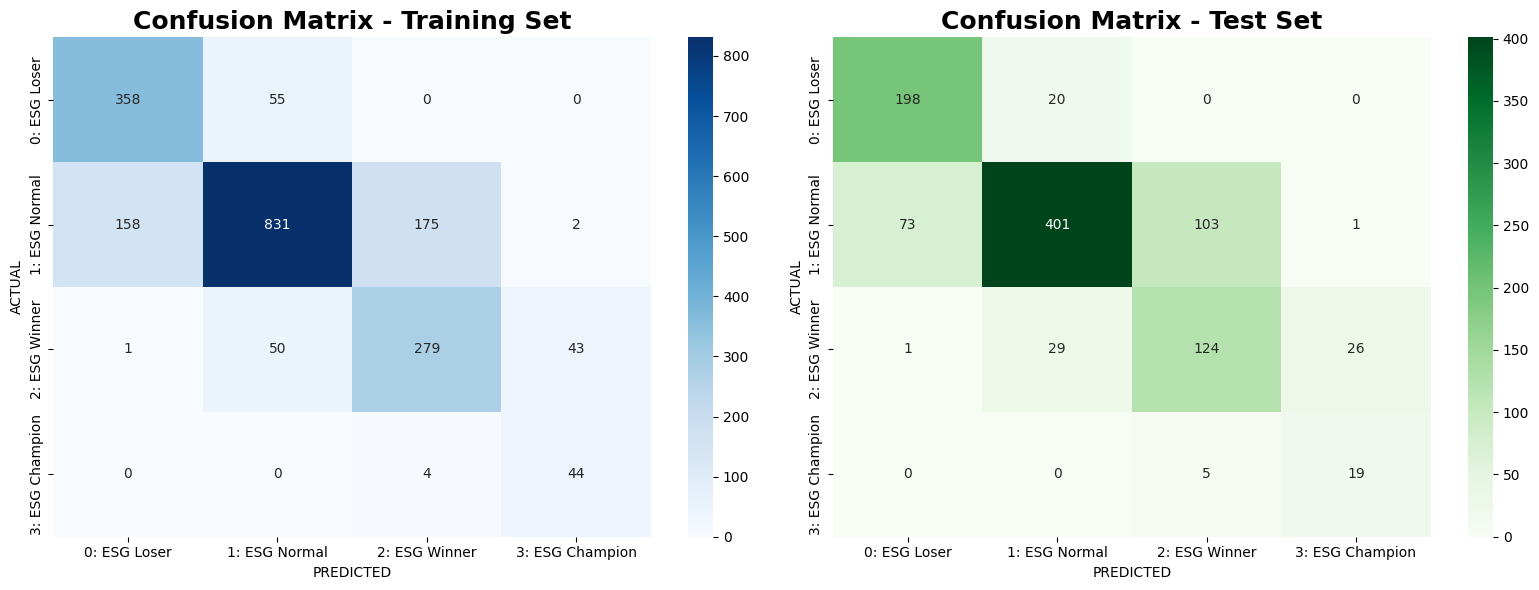


TRAINING SET CONFUSION MATRIX
PREDICTED        0: ESG Loser  1: ESG Normal  2: ESG Winner  3: ESG Champion
ACTUAL                                                                      
0: ESG Loser              358             55              0                0
1: ESG Normal             158            831            175                2
2: ESG Winner               1             50            279               43
3: ESG Champion             0              0              4               44

TEST SET CONFUSION MATRIX
PREDICTED        0: ESG Loser  1: ESG Normal  2: ESG Winner  3: ESG Champion
ACTUAL                                                                      
0: ESG Loser              198             20              0                0
1: ESG Normal              73            401            103                1
2: ESG Winner               1             29            124               26
3: ESG Champion             0              0              5               19


In [54]:
# Generate predictions for training set
y_train_pred_logit = logit_model.predict(X_train_scal)

# Create confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred_logit)
cm_test = confusion_matrix(y_test, y_pred_logit)

# Define ESG labels
labels = ['0: ESG Loser', '1: ESG Normal', '2: ESG Winner', '3: ESG Champion']

# Create DataFrames for better readability
df_cm_train = pd.DataFrame(cm_train, columns=labels, index=labels)
df_cm_train.index.name = 'ACTUAL'
df_cm_train.columns.name = 'PREDICTED'

df_cm_test = pd.DataFrame(cm_test, columns=labels, index=labels)
df_cm_test.index.name = 'ACTUAL'
df_cm_test.columns.name = 'PREDICTED'

# Visualize both confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set confusion matrix
sns.heatmap(df_cm_train, ax=axes[0], cmap="Blues", annot=True, fmt='g', cbar=True)
axes[0].set_title('Confusion Matrix - Training Set', fontsize=18, fontweight='bold')

# Test set confusion matrix
sns.heatmap(df_cm_test, ax=axes[1], cmap="Greens", annot=True, fmt='g', cbar=True)
axes[1].set_title('Confusion Matrix - Test Set', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("TRAINING SET CONFUSION MATRIX")
print("="*60)
print(df_cm_train)

print("\n" + "="*60)
print("TEST SET CONFUSION MATRIX")
print("="*60)
print(df_cm_test)


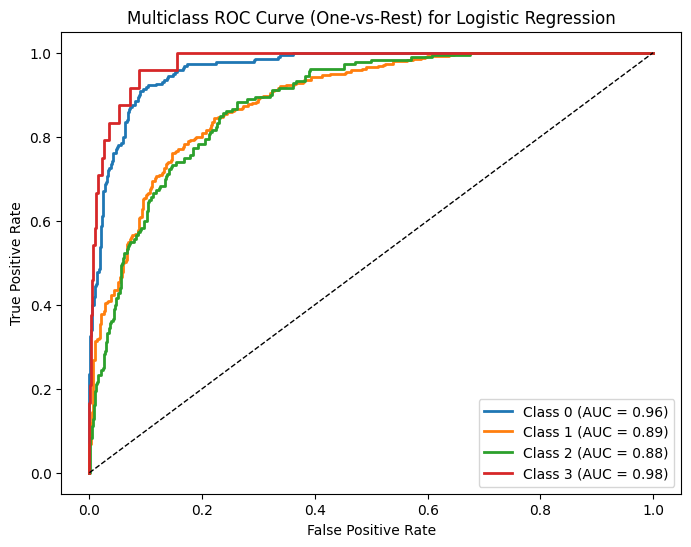

In [55]:
### RC Curve and AUC for Multiclass Logistic Regression

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarise true labels for one-vs-rest ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])
n_classes = y_test_bin.shape[1]

# Predicted probabilities
y_prob_logit = logit_model.predict_proba(X_test_scal)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_logit[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (One-vs-Rest) for Logistic Regression")
plt.legend()
plt.show()


In [56]:

importance = np.abs(logit_model.coef_[0])

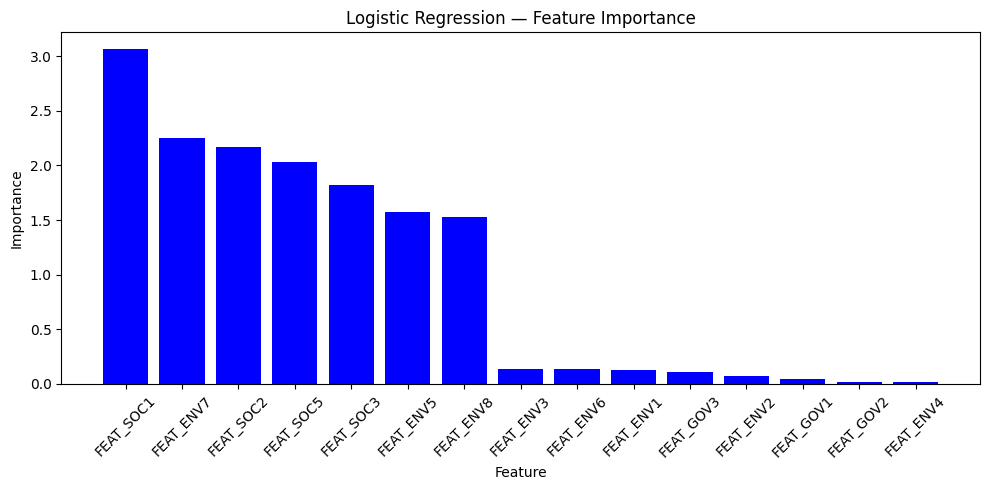

In [57]:
# Feature importance from multinomial logistic regression
feat_imp_logit = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': np.abs(logit_model.coef_[0])
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(feat_imp_logit['Feature'], feat_imp_logit['Importance'], color='blue')
plt.title('Logistic Regression — Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Gradient Boosting Classifier

In [58]:
# Ensure correct model
from sklearn.ensemble import GradientBoostingClassifier
GB_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
GB_model.fit(X_train, y_train)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

#### Evaluting Performs
##### Confusion Matrices, ROC Curves and Feature Importance

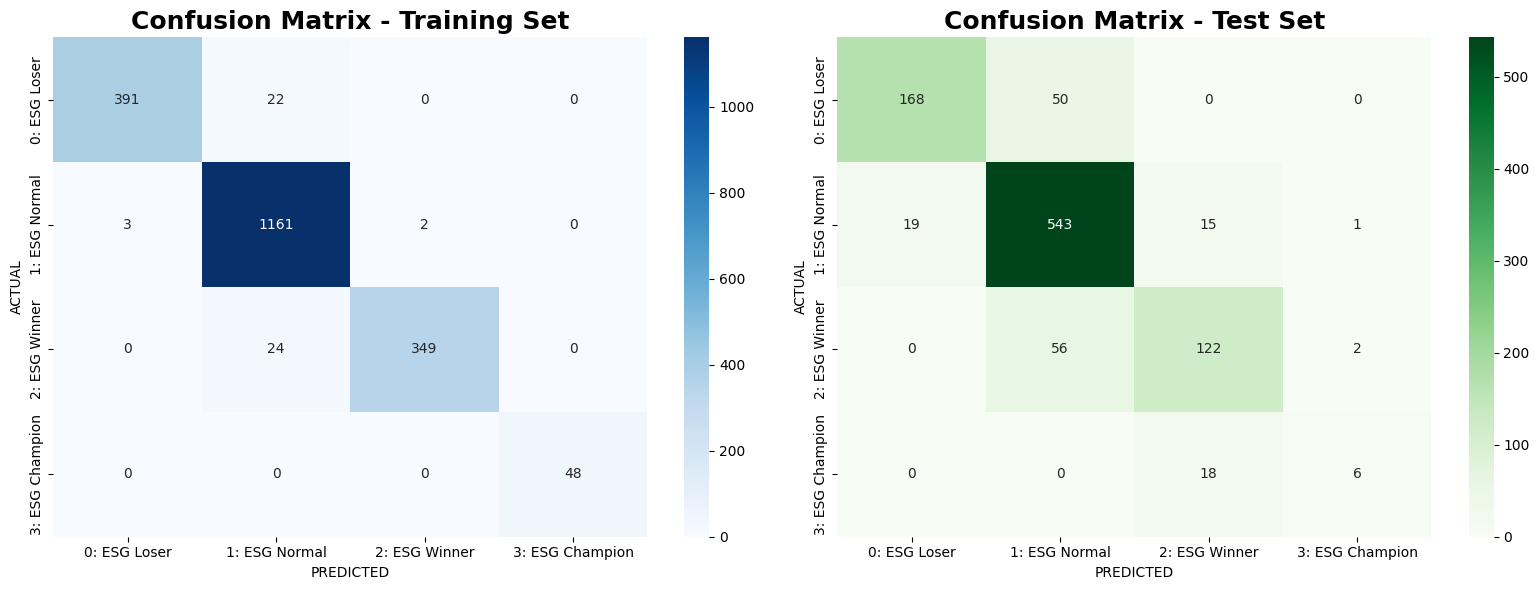


TRAINING SET CONFUSION MATRIX
PREDICTED        0: ESG Loser  1: ESG Normal  2: ESG Winner  3: ESG Champion
ACTUAL                                                                      
0: ESG Loser              391             22              0                0
1: ESG Normal               3           1161              2                0
2: ESG Winner               0             24            349                0
3: ESG Champion             0              0              0               48

TEST SET CONFUSION MATRIX
PREDICTED        0: ESG Loser  1: ESG Normal  2: ESG Winner  3: ESG Champion
ACTUAL                                                                      
0: ESG Loser              168             50              0                0
1: ESG Normal              19            543             15                1
2: ESG Winner               0             56            122                2
3: ESG Champion             0              0             18                6


In [59]:
# Generate predictions
y_train_pred_GB = GB_model.predict(X_train)
y_test_pred_GB = GB_model.predict(X_test)

# Create confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred_GB)
cm_test = confusion_matrix(y_test, y_test_pred_GB)

# Define ESG labels
labels = ['0: ESG Loser', '1: ESG Normal', '2: ESG Winner', '3: ESG Champion']

# Create DataFrames
df_cm_train = pd.DataFrame(cm_train, columns=labels, index=labels)
df_cm_train.index.name = 'ACTUAL'
df_cm_train.columns.name = 'PREDICTED'

df_cm_test = pd.DataFrame(cm_test, columns=labels, index=labels)
df_cm_test.index.name = 'ACTUAL'
df_cm_test.columns.name = 'PREDICTED'

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_cm_train, ax=axes[0], cmap="Blues", annot=True, fmt='g', cbar=True)
axes[0].set_title('Confusion Matrix - Training Set', fontsize=18, fontweight='bold')

sns.heatmap(df_cm_test, ax=axes[1], cmap="Greens", annot=True, fmt='g', cbar=True)
axes[1].set_title('Confusion Matrix - Test Set', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

# Printing
print("\n" + "="*60)
print("TRAINING SET CONFUSION MATRIX")
print("="*60)
print(df_cm_train)

print("\n" + "="*60)
print("TEST SET CONFUSION MATRIX")
print("="*60)
print(df_cm_test)


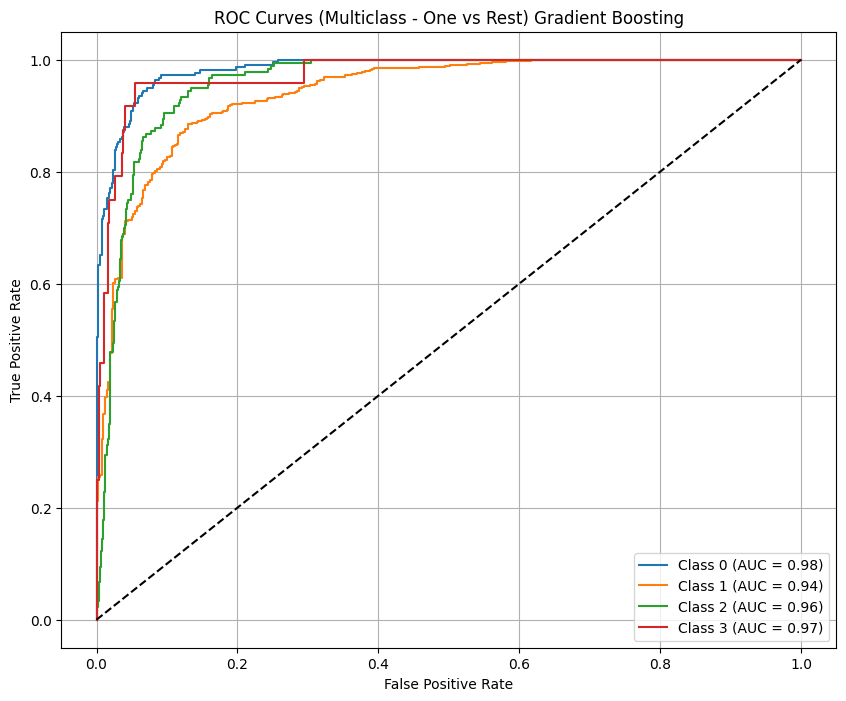

In [60]:
#### ROC Curve and AUC for Multiclass Gradient Boosting
# Number of classes
classes = [0, 1, 2, 3]

# Binarize the output
y_test_bin = label_binarize(y_test, classes=classes)

# Get predicted probabilities
y_proba_GB = GB_model.predict_proba(X_test)

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_GB[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# Plot diagonal line
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Multiclass - One vs Rest) Gradient Boosting')
plt.legend(loc='lower right')
plt.grid()
plt.show()

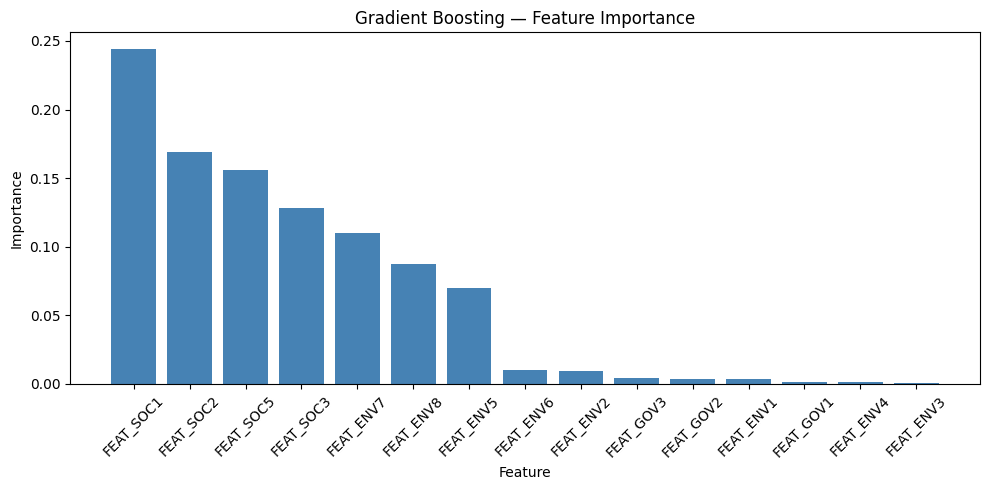

In [61]:
## feature importance from Gradient Boosting
feat_imp_gb = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': GB_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(feat_imp_gb['Feature'], feat_imp_gb['Importance'], color='steelblue')
plt.title('Gradient Boosting — Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Elastic Net Logistic Regression (regularisation)

In [62]:
# Train model
log_enet = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    max_iter=5000
)

log_enet.fit(X_train_scal, y_train)

# Predict
y_pred = log_enet.predict(X_test_scal)
y_proba_log_enet = log_enet.predict_proba(X_test_scal)

C:\Users\abdul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


#### Evaluating Performance
##### Confusion matrices, ROC curves and Feature Importance

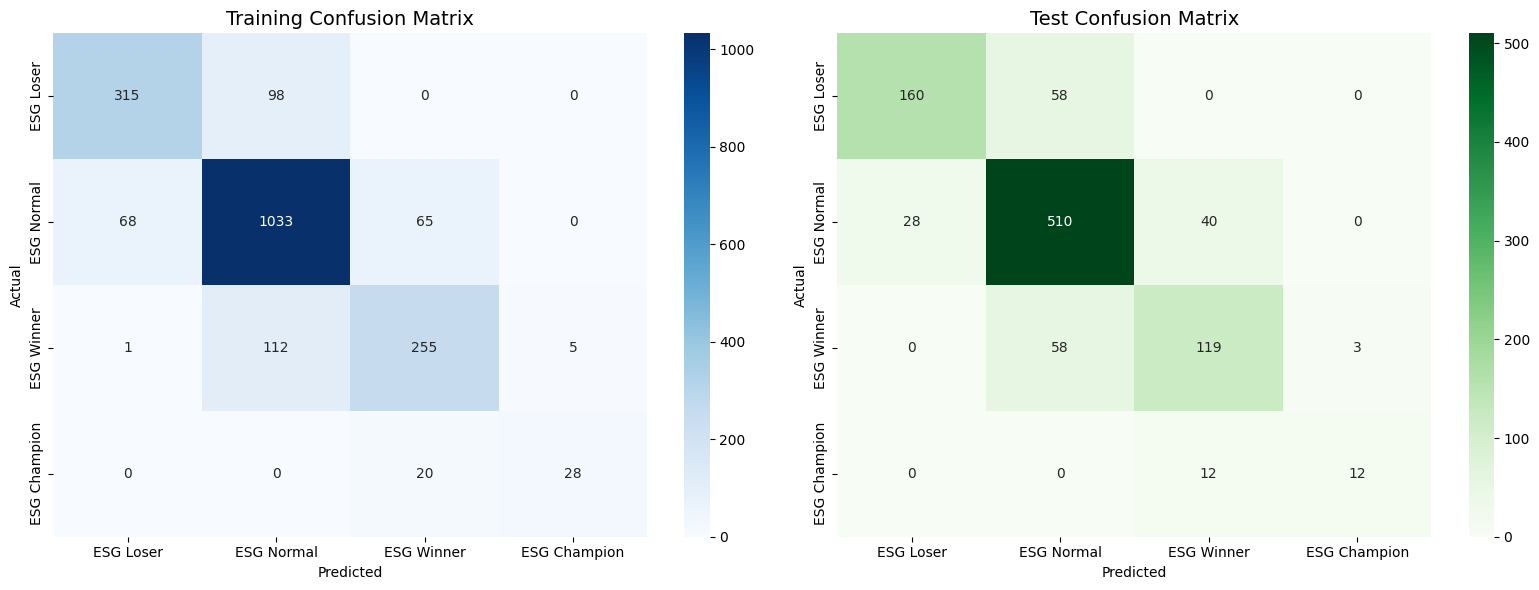

In [63]:
# Training predictions
y_train_pred_log_ent = log_enet.predict(X_train_scal)

# Test predictions
y_test_pred_log_ent = log_enet.predict(X_test_scal)

cm_train = confusion_matrix(y_train, y_train_pred_log_ent, labels=[0,1,2,3])
cm_test = confusion_matrix(y_test, y_test_pred_log_ent, labels=[0,1,2,3])

labels = ['ESG Loser', 'ESG Normal', 'ESG Winner', 'ESG Champion']

df_cm_train = pd.DataFrame(cm_train, index=labels, columns=labels)
df_cm_test = pd.DataFrame(cm_test, index=labels, columns=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train
sns.heatmap(df_cm_train, ax=axes[0], annot=True, cmap="Blues", fmt='g')
axes[0].set_title("Training Confusion Matrix", fontsize=14)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Test
sns.heatmap(df_cm_test, ax=axes[1], annot=True, cmap="Greens", fmt='g')
axes[1].set_title("Test Confusion Matrix", fontsize=14)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

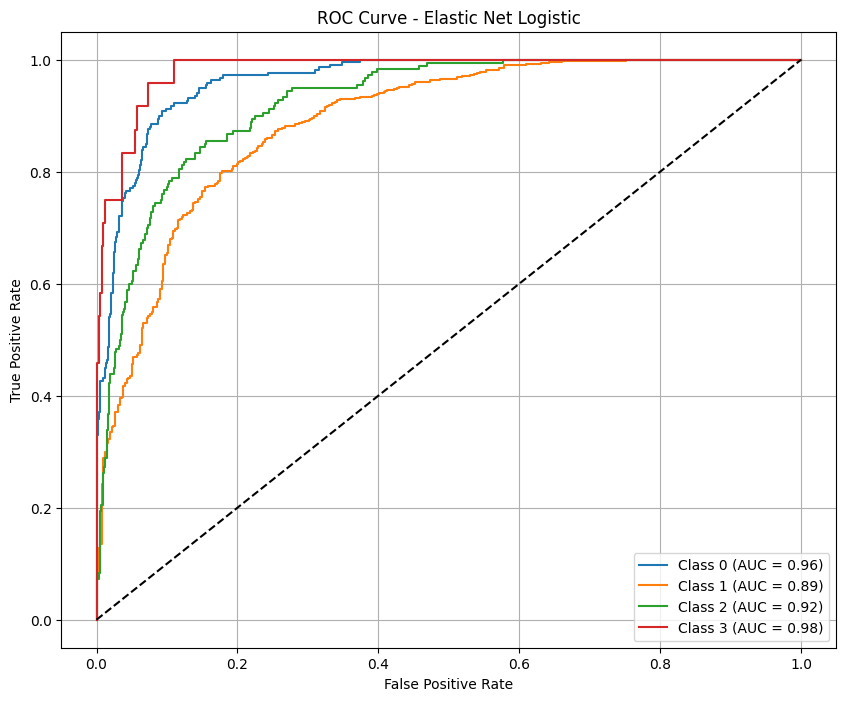

In [64]:
## roc curves printing
classes = [0,1,2,3]

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_log_enet[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Elastic Net Logistic")
plt.legend()
plt.grid()
plt.show()

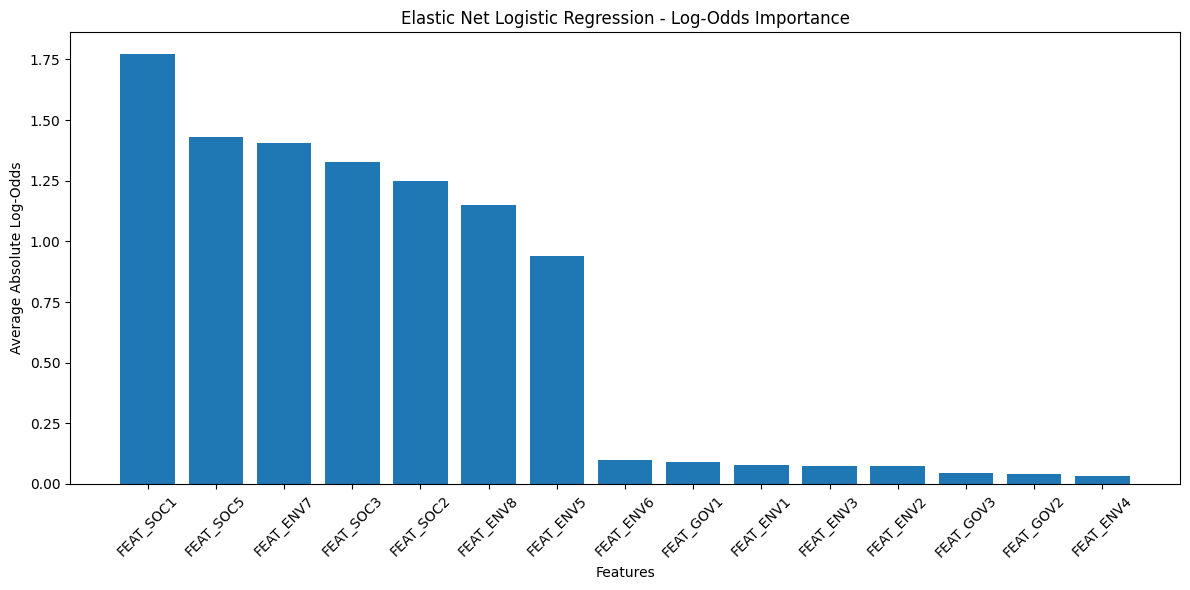


Dropped Features: []


In [65]:
# Get actual feature names from the data
feature_names = data.drop(columns=['CATEGORY']).columns.tolist()

# Extract coefficients
coef = log_enet.coef_

# Compute average absolute log-odds
log_odds = np.mean(np.abs(coef), axis=0)

# DataFrame
log_odds_df = pd.DataFrame({
    'Feature': feature_names,
    'Log_Odds_Importance': log_odds
}).sort_values(by='Log_Odds_Importance', ascending=False)

# Plot
plt.figure(figsize=(12,6))
plt.bar(log_odds_df['Feature'], log_odds_df['Log_Odds_Importance'])

plt.title("Elastic Net Logistic Regression - Log-Odds Importance")
plt.xlabel("Features")
plt.ylabel("Average Absolute Log-Odds")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Dropped features
dropped_features = [feature_names[i] for i in range(len(feature_names)) if (coef[:, i] == 0).all()]

print("\nDropped Features:", dropped_features)

#### High Predictive Accuracy Model: Random Forest 
##### Evaluating Performance with Confusion Matrices and ROC Curves

Train Accuracy: 0.731
Test Accuracy: 0.694


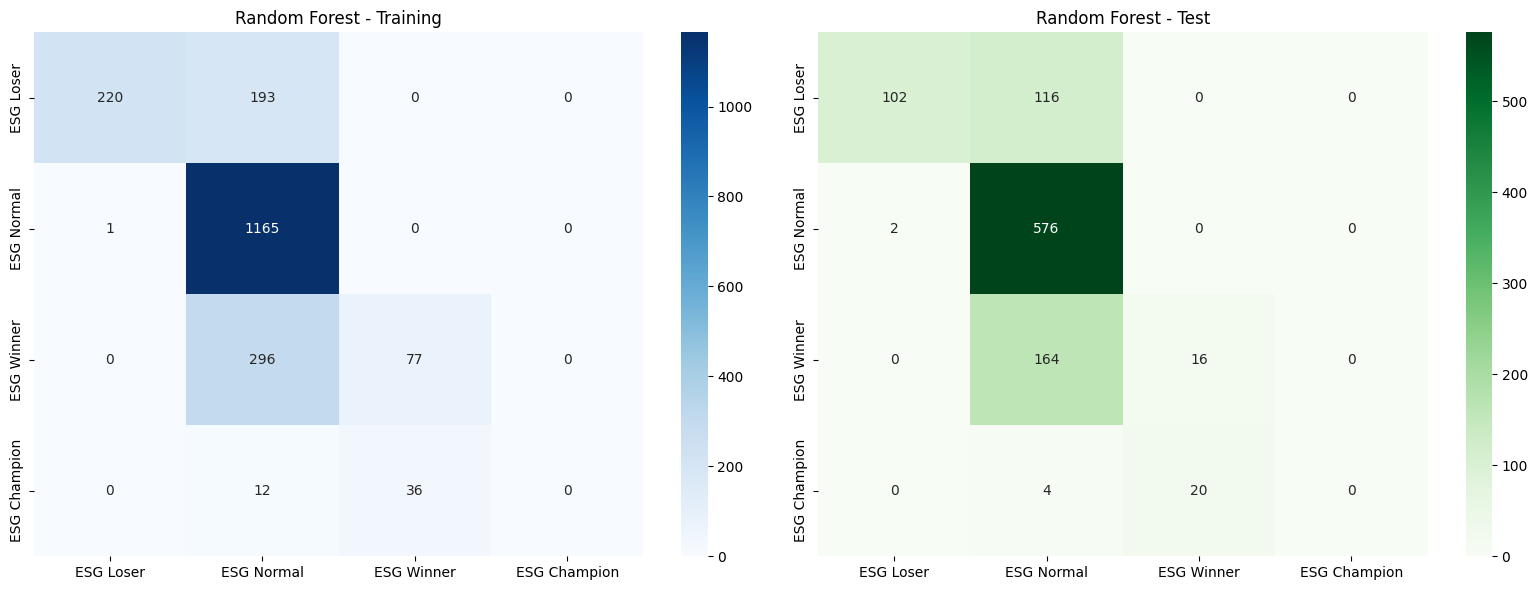


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.98      0.47      0.63       218
           1       0.67      1.00      0.80       578
           2       0.44      0.09      0.15       180
           3       0.00      0.00      0.00        24

    accuracy                           0.69      1000
   macro avg       0.52      0.39      0.40      1000
weighted avg       0.68      0.69      0.63      1000


ROC AUC: 0.9439715961384787


C:\Users\abdul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abdul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\abdul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

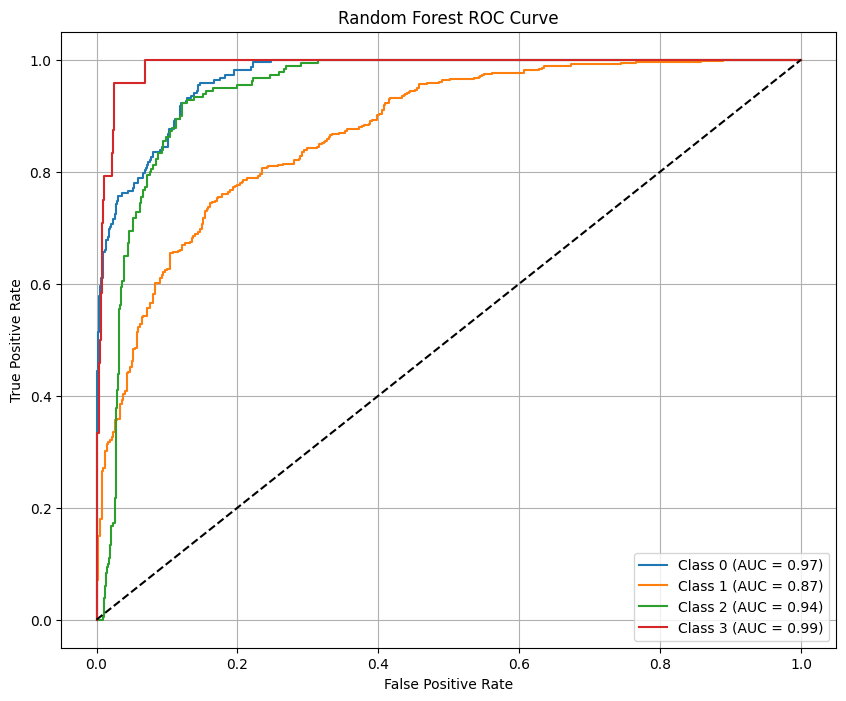

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

# ----------------------------
# 1. Fit Random Forest
# ----------------------------
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

# ----------------------------
# 2. Predictions
# ----------------------------
y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)

# ----------------------------
# 3. Accuracy (Train vs Test)
# ----------------------------
print("Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))

# ----------------------------
# 4. Confusion Matrices
# ----------------------------
labels = ['ESG Loser', 'ESG Normal', 'ESG Winner', 'ESG Champion']

cm_train = confusion_matrix(y_train, y_train_pred_rf, labels=[0,1,2,3])
cm_test = confusion_matrix(y_test, y_test_pred_rf, labels=[0,1,2,3])

df_train = pd.DataFrame(cm_train, index=labels, columns=labels)
df_test = pd.DataFrame(cm_test, index=labels, columns=labels)

fig, axes = plt.subplots(1, 2, figsize=(16,6))

sns.heatmap(df_train, ax=axes[0], annot=True, cmap="Blues", fmt='g')
axes[0].set_title("Random Forest - Training")

sns.heatmap(df_test, ax=axes[1], annot=True, cmap="Greens", fmt='g')
axes[1].set_title("Random Forest - Test")

plt.tight_layout()
plt.show()

# ----------------------------
# 5. Classification Report
# ----------------------------
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred_rf))

# ----------------------------
# 6. ROC AUC Score
# ----------------------------
roc_auc = roc_auc_score(y_test, y_proba_rf, multi_class='ovr')
print("\nROC AUC:", roc_auc)

# ----------------------------
# 7. ROC Curve
# ----------------------------


classes = [0,1,2,3]
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10,8))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_rf[:, i])
    roc_auc_class = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc_class:.2f})')

plt.plot([0,1], [0,1], 'k--')
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

###### Random Forest Feature Importance

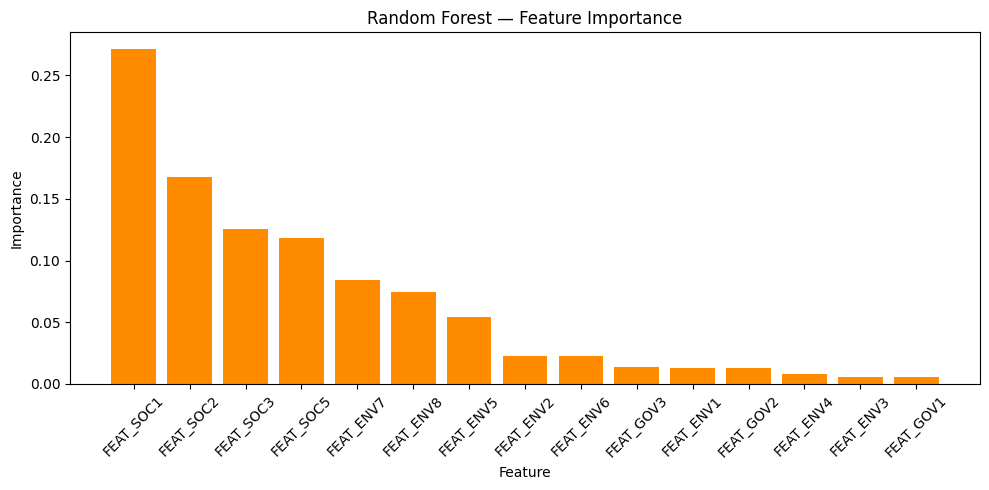

In [67]:
feat_imp_rf = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(feat_imp_rf['Feature'], feat_imp_rf['Importance'], color='darkorange')
plt.title('Random Forest — Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Comparing Predictive Accuracy of the fitted models
##### Comparing AUC scores for the fitted models

In [68]:
acc_log = accuracy_score(y_test, y_pred_logit)
acc_gb = accuracy_score(y_test, y_test_pred_GB)
acc_log_ent = accuracy_score(y_test, y_test_pred_log_ent)
acc_rf = accuracy_score(y_test, y_test_pred_rf)

In [69]:
print( accuracy_score(y_test, y_pred_logit))
print( accuracy_score(y_test, y_test_pred_GB))
print( accuracy_score(y_test, y_test_pred_log_ent))
print( accuracy_score(y_test, y_test_pred_rf))

0.742
0.839
0.801
0.694


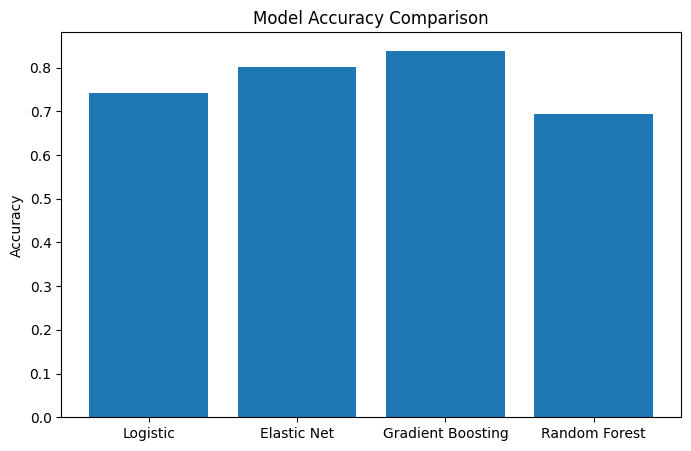

In [70]:
models = ['Logistic', 'Elastic Net', 'Gradient Boosting', 'Random Forest']
accuracy_scores = [acc_log, acc_log_ent, acc_gb, acc_rf]

plt.figure(figsize=(8,5))
plt.bar(models, accuracy_scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


#### Shap plot for Baseline Model

In [71]:
import shap

C:\Users\abdul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.


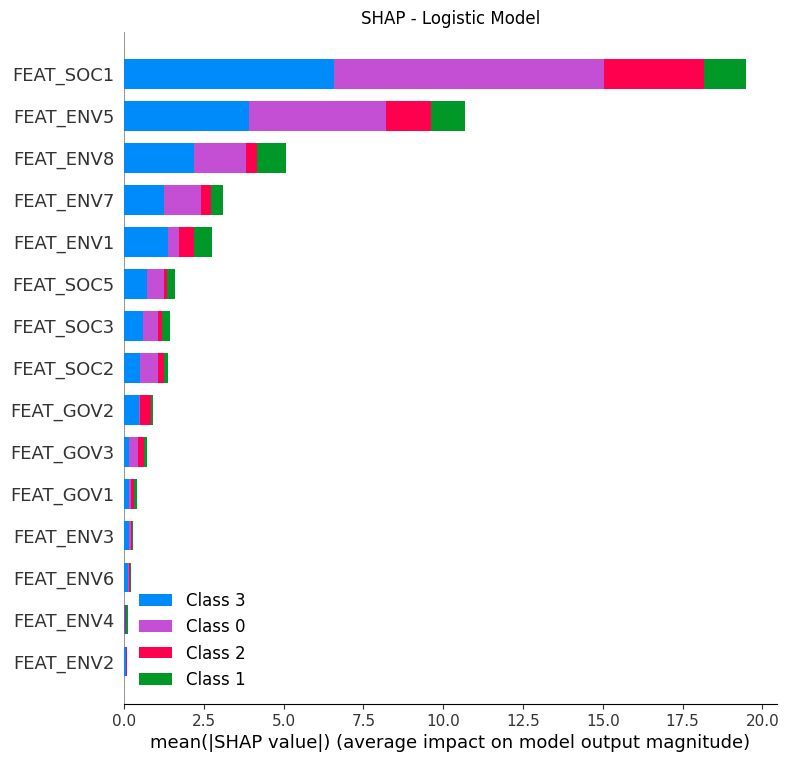

In [72]:
explainer_log = shap.LinearExplainer(logit_model, X_train)
shap_values_log = explainer_log(X_test)
plt.figure(figsize=(8,3))

shap.summary_plot(shap_values_log, X_test, show=False)

plt.title("SHAP - Logistic Model")
plt.show()

### Cross-Validation

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=2000),
    'Elastic Net':         LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=5000),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

cv_results = {}
for name, model in models_cv.items():
    # Use scaled data for logistic models, unscaled for tree-based
    X_cv = X_train_scal if 'Logistic' in name or 'Elastic' in name else X_train
    scores = cross_validate(model, X_cv, y_train, cv=cv,
                            scoring=['accuracy', 'f1_macro'],
                            return_train_score=True)
    cv_results[name] = {
        'Train Acc Mean':  scores['train_accuracy'].mean(),
        'Train Acc Std':   scores['train_accuracy'].std(),
        'Test Acc Mean':   scores['test_accuracy'].mean(),
        'Test Acc Std':    scores['test_accuracy'].std(),
        'F1 Macro Mean':   scores['test_f1_macro'].mean(),
        'F1 Macro Std':    scores['test_f1_macro'].std()
    }

cv_df = pd.DataFrame(cv_results).T.round(4)
print(cv_df)

C:\Users\abdul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\abdul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\abdul

                     Train Acc Mean  Train Acc Std  Test Acc Mean  \
Logistic Regression          0.7548         0.0044         0.7425   
Elastic Net                  0.8147         0.0034         0.8050   
Gradient Boosting            0.9790         0.0025         0.8560   
Random Forest                0.7259         0.0062         0.6800   

                     Test Acc Std  F1 Macro Mean  F1 Macro Std  
Logistic Regression        0.0282         0.6843        0.0547  
Elastic Net                0.0249         0.7095        0.0754  
Gradient Boosting          0.0249         0.6868        0.0736  
Random Forest              0.0219         0.3764        0.0308  


### Predictive Accuracy on the test test using Cross-validation

                     Test Accuracy  Macro F1  Weighted F1  Macro AUC
Logistic Regression          0.742    0.6833       0.7485     0.9289
Elastic Net                  0.801    0.7322       0.7983     0.9401
Gradient Boosting            0.839    0.7017       0.8323     0.9650
Random Forest                0.694    0.3957       0.6278     0.9440


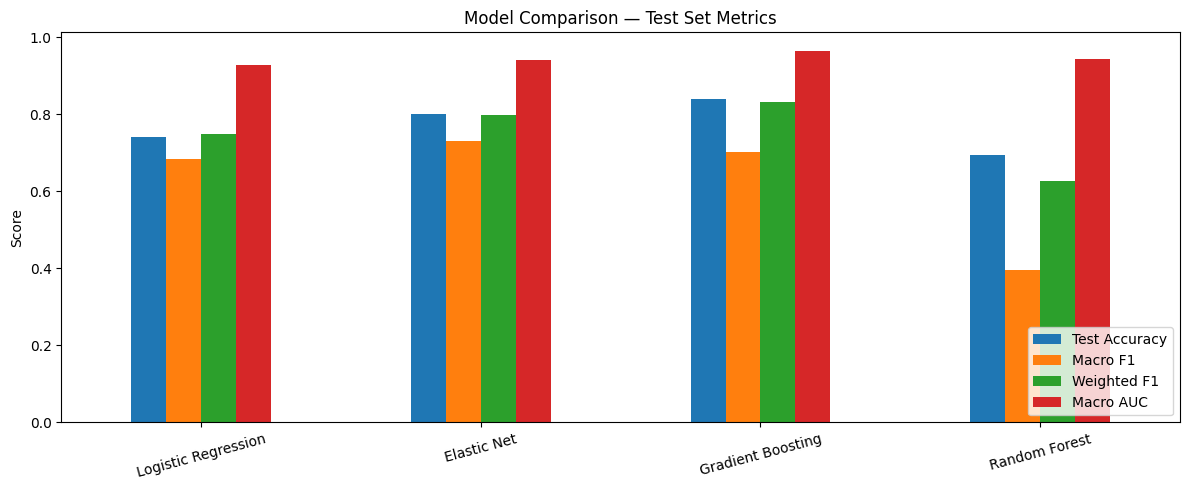

In [74]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

results = {}
model_preds = {
    'Logistic Regression': (y_pred_logit,        logit_model.predict_proba(X_test_scal)),
    'Elastic Net':          (y_test_pred_log_ent, log_enet.predict_proba(X_test_scal)),
    'Gradient Boosting':    (y_test_pred_GB,      GB_model.predict_proba(X_test)),
    'Random Forest':        (y_test_pred_rf,      rf_model.predict_proba(X_test))
}

for name, (preds, proba) in model_preds.items():
    results[name] = {
        'Test Accuracy':  accuracy_score(y_test, preds),
        'Macro F1':       f1_score(y_test, preds, average='macro'),
        'Weighted F1':    f1_score(y_test, preds, average='weighted'),
        'Macro AUC':      roc_auc_score(y_test, proba, multi_class='ovr', average='macro')
    }

results_df = pd.DataFrame(results).T.round(4)
print(results_df)

# Visualise
results_df.plot(kind='bar', figsize=(12, 5))
plt.title('Model Comparison — Test Set Metrics')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Error-Classifcation Analysis

In [75]:
# Build an error dataframe for Logistic Regression

error_df = X_test.copy()
error_df['Actual']    = y_test.values
error_df['Predicted'] = y_pred_logit  # Change to y_test_pred_log_ent, y_test_pred_GB, or y_test_pred_rf as needed

category_map = {0: 'ESG Loser', 1: 'ESG Normal', 2: 'ESG Winner', 3: 'ESG Champion'}
error_df['Actual_Label']    = error_df['Actual'].map(category_map)
error_df['Predicted_Label'] = error_df['Predicted'].map(category_map)
error_df['Correct']         = error_df['Actual'] == error_df['Predicted']

misclassified = error_df[~error_df['Correct']]

# 1. Error type frequency
error_pairs = misclassified.groupby(['Actual_Label', 'Predicted_Label']).size() \
                           .reset_index(name='Count') \
                           .sort_values('Count', ascending=False)
print("Most Common Misclassification Pairs:")
print(error_pairs.head(10))

# 2. Severity: flag high-consequence errors (Loser predicted as Champion or vice versa)
high_severity = misclassified[
    ((misclassified['Actual'] == 0) & (misclassified['Predicted'] == 3)) |
    ((misclassified['Actual'] == 3) & (misclassified['Predicted'] == 0))
]
print(f"\nHigh-severity errors (Loser↔Champion): {len(high_severity)}")

# 3. Adjacency error rate (off by 1 class vs off by 2+)
misclassified = misclassified.copy()
misclassified['Gap'] = (misclassified['Actual'] - misclassified['Predicted']).abs()
print("\nMisclassification gap distribution:")
print(misclassified['Gap'].value_counts().sort_index())

# 4. Per-class error rate
for cls in [0, 1, 2, 3]:
    cls_total = (error_df['Actual'] == cls).sum()
    cls_errors = ((error_df['Actual'] == cls) & (~error_df['Correct'])).sum()
    print(f"Class {category_map[cls]}: {cls_errors}/{cls_total} errors ({100*cls_errors/cls_total:.1f}%)")

Most Common Misclassification Pairs:
   Actual_Label Predicted_Label  Count
4    ESG Normal      ESG Winner    103
3    ESG Normal       ESG Loser     73
7    ESG Winner      ESG Normal     29
5    ESG Winner    ESG Champion     26
1     ESG Loser      ESG Normal     20
0  ESG Champion      ESG Winner      5
2    ESG Normal    ESG Champion      1
6    ESG Winner       ESG Loser      1

High-severity errors (Loser↔Champion): 0

Misclassification gap distribution:
Gap
1    256
2      2
Name: count, dtype: int64
Class ESG Loser: 20/218 errors (9.2%)
Class ESG Normal: 177/578 errors (30.6%)
Class ESG Winner: 56/180 errors (31.1%)
Class ESG Champion: 5/24 errors (20.8%)


In [76]:
# Build an error dataframe for  Elastic net Logistic Regression

error_df = X_test.copy()
error_df['Actual']    = y_test.values
error_df['Predicted'] = y_test_pred_log_ent  # Change to y_test_pred_log_ent, y_test_pred_GB, or y_test_pred_rf as needed

category_map = {0: 'ESG Loser', 1: 'ESG Normal', 2: 'ESG Winner', 3: 'ESG Champion'}
error_df['Actual_Label']    = error_df['Actual'].map(category_map)
error_df['Predicted_Label'] = error_df['Predicted'].map(category_map)
error_df['Correct']         = error_df['Actual'] == error_df['Predicted']

misclassified = error_df[~error_df['Correct']]

# 1. Error type frequency
error_pairs = misclassified.groupby(['Actual_Label', 'Predicted_Label']).size() \
                           .reset_index(name='Count') \
                           .sort_values('Count', ascending=False)
print("Most Common Misclassification Pairs:")
print(error_pairs.head(10))

# 2. Severity: flag high-consequence errors (Loser predicted as Champion or vice versa)
high_severity = misclassified[
    ((misclassified['Actual'] == 0) & (misclassified['Predicted'] == 3)) |
    ((misclassified['Actual'] == 3) & (misclassified['Predicted'] == 0))
]
print(f"\nHigh-severity errors (Loser↔Champion): {len(high_severity)}")

# 3. Adjacency error rate (off by 1 class vs off by 2+)
misclassified = misclassified.copy()
misclassified['Gap'] = (misclassified['Actual'] - misclassified['Predicted']).abs()
print("\nMisclassification gap distribution:")
print(misclassified['Gap'].value_counts().sort_index())

# 4. Per-class error rate
for cls in [0, 1, 2, 3]:
    cls_total = (error_df['Actual'] == cls).sum()
    cls_errors = ((error_df['Actual'] == cls) & (~error_df['Correct'])).sum()
    print(f"Class {category_map[cls]}: {cls_errors}/{cls_total} errors ({100*cls_errors/cls_total:.1f}%)")

Most Common Misclassification Pairs:
   Actual_Label Predicted_Label  Count
1     ESG Loser      ESG Normal     58
5    ESG Winner      ESG Normal     58
3    ESG Normal      ESG Winner     40
2    ESG Normal       ESG Loser     28
0  ESG Champion      ESG Winner     12
4    ESG Winner    ESG Champion      3

High-severity errors (Loser↔Champion): 0

Misclassification gap distribution:
Gap
1    199
Name: count, dtype: int64
Class ESG Loser: 58/218 errors (26.6%)
Class ESG Normal: 68/578 errors (11.8%)
Class ESG Winner: 61/180 errors (33.9%)
Class ESG Champion: 12/24 errors (50.0%)


In [77]:
# --- Build an error dataframe for Gradient Boosting

error_df = X_test.copy()
error_df['Actual']    = y_test.values
error_df['Predicted'] = y_test_pred_GB

category_map = {0: 'ESG Loser', 1: 'ESG Normal', 2: 'ESG Winner', 3: 'ESG Champion'}
error_df['Actual_Label']    = error_df['Actual'].map(category_map)
error_df['Predicted_Label'] = error_df['Predicted'].map(category_map)
error_df['Correct']         = error_df['Actual'] == error_df['Predicted']

misclassified = error_df[~error_df['Correct']]

# 1. Error type frequency
error_pairs = misclassified.groupby(['Actual_Label', 'Predicted_Label']).size() \
                           .reset_index(name='Count') \
                           .sort_values('Count', ascending=False)
print("Most Common Misclassification Pairs:")
print(error_pairs.head(10))

# 2. Severity: flag high-consequence errors (Loser predicted as Champion or vice versa)
high_severity = misclassified[
    ((misclassified['Actual'] == 0) & (misclassified['Predicted'] == 3)) |
    ((misclassified['Actual'] == 3) & (misclassified['Predicted'] == 0))
]
print(f"\nHigh-severity errors (Loser↔Champion): {len(high_severity)}")

# 3. Adjacency error rate (off by 1 class vs off by 2+)
misclassified = misclassified.copy()
misclassified['Gap'] = (misclassified['Actual'] - misclassified['Predicted']).abs()
print("\nMisclassification gap distribution:")
print(misclassified['Gap'].value_counts().sort_index())

# 4. Per-class error rate
for cls in [0, 1, 2, 3]:
    cls_total = (error_df['Actual'] == cls).sum()
    cls_errors = ((error_df['Actual'] == cls) & (~error_df['Correct'])).sum()
    print(f"Class {category_map[cls]}: {cls_errors}/{cls_total} errors ({100*cls_errors/cls_total:.1f}%)")

Most Common Misclassification Pairs:
   Actual_Label Predicted_Label  Count
6    ESG Winner      ESG Normal     56
1     ESG Loser      ESG Normal     50
3    ESG Normal       ESG Loser     19
0  ESG Champion      ESG Winner     18
4    ESG Normal      ESG Winner     15
5    ESG Winner    ESG Champion      2
2    ESG Normal    ESG Champion      1

High-severity errors (Loser↔Champion): 0

Misclassification gap distribution:
Gap
1    160
2      1
Name: count, dtype: int64
Class ESG Loser: 50/218 errors (22.9%)
Class ESG Normal: 35/578 errors (6.1%)
Class ESG Winner: 58/180 errors (32.2%)
Class ESG Champion: 18/24 errors (75.0%)


In [78]:
# Build an error dataframe for t Random Forest

error_df = X_test.copy()
error_df['Actual']    = y_test.values
error_df['Predicted'] = y_test_pred_rf 

category_map = {0: 'ESG Loser', 1: 'ESG Normal', 2: 'ESG Winner', 3: 'ESG Champion'}
error_df['Actual_Label']    = error_df['Actual'].map(category_map)
error_df['Predicted_Label'] = error_df['Predicted'].map(category_map)
error_df['Correct']         = error_df['Actual'] == error_df['Predicted']

misclassified = error_df[~error_df['Correct']]

# 1. Error type frequency
error_pairs = misclassified.groupby(['Actual_Label', 'Predicted_Label']).size() \
                           .reset_index(name='Count') \
                           .sort_values('Count', ascending=False)
print("Most Common Misclassification Pairs:")
print(error_pairs.head(10))

# 2. Severity: flag high-consequence errors (Loser predicted as Champion or vice versa)
high_severity = misclassified[
    ((misclassified['Actual'] == 0) & (misclassified['Predicted'] == 3)) |
    ((misclassified['Actual'] == 3) & (misclassified['Predicted'] == 0))
]
print(f"\nHigh-severity errors (Loser↔Champion): {len(high_severity)}")

# 3. Adjacency error rate (off by 1 class vs off by 2+)
misclassified = misclassified.copy()
misclassified['Gap'] = (misclassified['Actual'] - misclassified['Predicted']).abs()
print("\nMisclassification gap distribution:")
print(misclassified['Gap'].value_counts().sort_index())

# 4. Per-class error rate
for cls in [0, 1, 2, 3]:
    cls_total = (error_df['Actual'] == cls).sum()
    cls_errors = ((error_df['Actual'] == cls) & (~error_df['Correct'])).sum()
    print(f"Class {category_map[cls]}: {cls_errors}/{cls_total} errors ({100*cls_errors/cls_total:.1f}%)")

Most Common Misclassification Pairs:
   Actual_Label Predicted_Label  Count
4    ESG Winner      ESG Normal    164
2     ESG Loser      ESG Normal    116
1  ESG Champion      ESG Winner     20
0  ESG Champion      ESG Normal      4
3    ESG Normal       ESG Loser      2

High-severity errors (Loser↔Champion): 0

Misclassification gap distribution:
Gap
1    302
2      4
Name: count, dtype: int64
Class ESG Loser: 116/218 errors (53.2%)
Class ESG Normal: 2/578 errors (0.3%)
Class ESG Winner: 164/180 errors (91.1%)
Class ESG Champion: 24/24 errors (100.0%)


### Sensitivity Analysis

In [79]:
# ── Sensitivity Analysis: drop top feature from each model and compare accuracy ──

from sklearn.metrics import accuracy_score

# ── 1. Logistic Regression ──
top_feature_log = log_odds_df['Feature'].iloc[0]  # top feature by abs log-odds

X_train_scal_df = pd.DataFrame(X_train_scal, columns=X_train.columns)
X_test_scal_df  = pd.DataFrame(X_test_scal,  columns=X_test.columns)

X_train_log_reduced = X_train_scal_df.drop(columns=[top_feature_log])
X_test_log_reduced  = X_test_scal_df.drop(columns=[top_feature_log])

log_reduced = LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=2000)
log_reduced.fit(X_train_log_reduced, y_train)
acc_log_reduced = accuracy_score(y_test, log_reduced.predict(X_test_log_reduced))

print("── Logistic Regression ──")
print(f"Full model accuracy:    {accuracy_score(y_test, y_pred_logit):.4f}")
print(f"Without {top_feature_log}: {acc_log_reduced:.4f}")
print(f"Accuracy drop:          {accuracy_score(y_test, y_pred_logit) - acc_log_reduced:.4f}\n")


# ── 2. Elastic Net Logistic Regression ──
top_feature_enet = log_odds_df['Feature'].iloc[0]  # reuses same log-odds importance df

X_train_enet_reduced = X_train_scal_df.drop(columns=[top_feature_enet])
X_test_enet_reduced  = X_test_scal_df.drop(columns=[top_feature_enet])

enet_reduced = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=5000)
enet_reduced.fit(X_train_enet_reduced, y_train)
acc_enet_reduced = accuracy_score(y_test, enet_reduced.predict(X_test_enet_reduced))

print("── Elastic Net Logistic Regression ──")
print(f"Full model accuracy:    {accuracy_score(y_test, y_test_pred_log_ent):.4f}")
print(f"Without {top_feature_enet}: {acc_enet_reduced:.4f}")
print(f"Accuracy drop:          {accuracy_score(y_test, y_test_pred_log_ent) - acc_enet_reduced:.4f}\n")


# ── 3. Gradient Boosting ──
top_feature_gb = feat_imp_gb['Feature'].iloc[0]

X_train_gb_reduced = X_train.drop(columns=[top_feature_gb])
X_test_gb_reduced  = X_test.drop(columns=[top_feature_gb])

gb_reduced = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_reduced.fit(X_train_gb_reduced, y_train)
acc_gb_reduced = accuracy_score(y_test, gb_reduced.predict(X_test_gb_reduced))

print("── Gradient Boosting ──")
print(f"Full model accuracy:    {accuracy_score(y_test, y_test_pred_GB):.4f}")
print(f"Without {top_feature_gb}: {acc_gb_reduced:.4f}")
print(f"Accuracy drop:          {accuracy_score(y_test, y_test_pred_GB) - acc_gb_reduced:.4f}\n")


# ── 4. Random Forest ──
top_feature_rf = feat_imp_rf['Feature'].iloc[0]

X_train_rf_reduced = X_train.drop(columns=[top_feature_rf])
X_test_rf_reduced  = X_test.drop(columns=[top_feature_rf])

rf_reduced = RandomForestClassifier(n_estimators=200, random_state=42)
rf_reduced.fit(X_train_rf_reduced, y_train)
acc_rf_reduced = accuracy_score(y_test, rf_reduced.predict(X_test_rf_reduced))

print("── Random Forest ──")
print(f"Full model accuracy:    {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"Without {top_feature_rf}: {acc_rf_reduced:.4f}")
print(f"Accuracy drop:          {accuracy_score(y_test, y_test_pred_rf) - acc_rf_reduced:.4f}\n")


# ── Summary table ──
sensitivity_summary = pd.DataFrame({
    'Model':            ['Logistic Regression', 'Elastic Net', 'Gradient Boosting', 'Random Forest'],
    'Top Feature':      [top_feature_log, top_feature_enet, top_feature_gb, top_feature_rf],
    'Full Accuracy':    [accuracy_score(y_test, y_pred_logit),
                         accuracy_score(y_test, y_test_pred_log_ent),
                         accuracy_score(y_test, y_test_pred_GB),
                         accuracy_score(y_test, y_test_pred_rf)],
    'Reduced Accuracy': [acc_log_reduced, acc_enet_reduced, acc_gb_reduced, acc_rf_reduced],
    'Accuracy Drop':    [accuracy_score(y_test, y_pred_logit)    - acc_log_reduced,
                         accuracy_score(y_test, y_test_pred_log_ent) - acc_enet_reduced,
                         accuracy_score(y_test, y_test_pred_GB)  - acc_gb_reduced,
                         accuracy_score(y_test, y_test_pred_rf)  - acc_rf_reduced]
}).round(4)

print(sensitivity_summary)

── Logistic Regression ──
Full model accuracy:    0.7420
Without FEAT_SOC1: 0.5360
Accuracy drop:          0.2060

── Elastic Net Logistic Regression ──
Full model accuracy:    0.8010
Without FEAT_SOC1: 0.6370
Accuracy drop:          0.1640



C:\Users\abdul\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


── Gradient Boosting ──
Full model accuracy:    0.8390
Without FEAT_SOC1: 0.6800
Accuracy drop:          0.1590

── Random Forest ──
Full model accuracy:    0.6940
Without FEAT_SOC1: 0.6770
Accuracy drop:          0.0170

                 Model Top Feature  Full Accuracy  Reduced Accuracy  \
0  Logistic Regression   FEAT_SOC1          0.742             0.536   
1          Elastic Net   FEAT_SOC1          0.801             0.637   
2    Gradient Boosting   FEAT_SOC1          0.839             0.680   
3        Random Forest   FEAT_SOC1          0.694             0.677   

   Accuracy Drop  
0          0.206  
1          0.164  
2          0.159  
3          0.017  


### Visualisaing Classification Boundaries using PCA

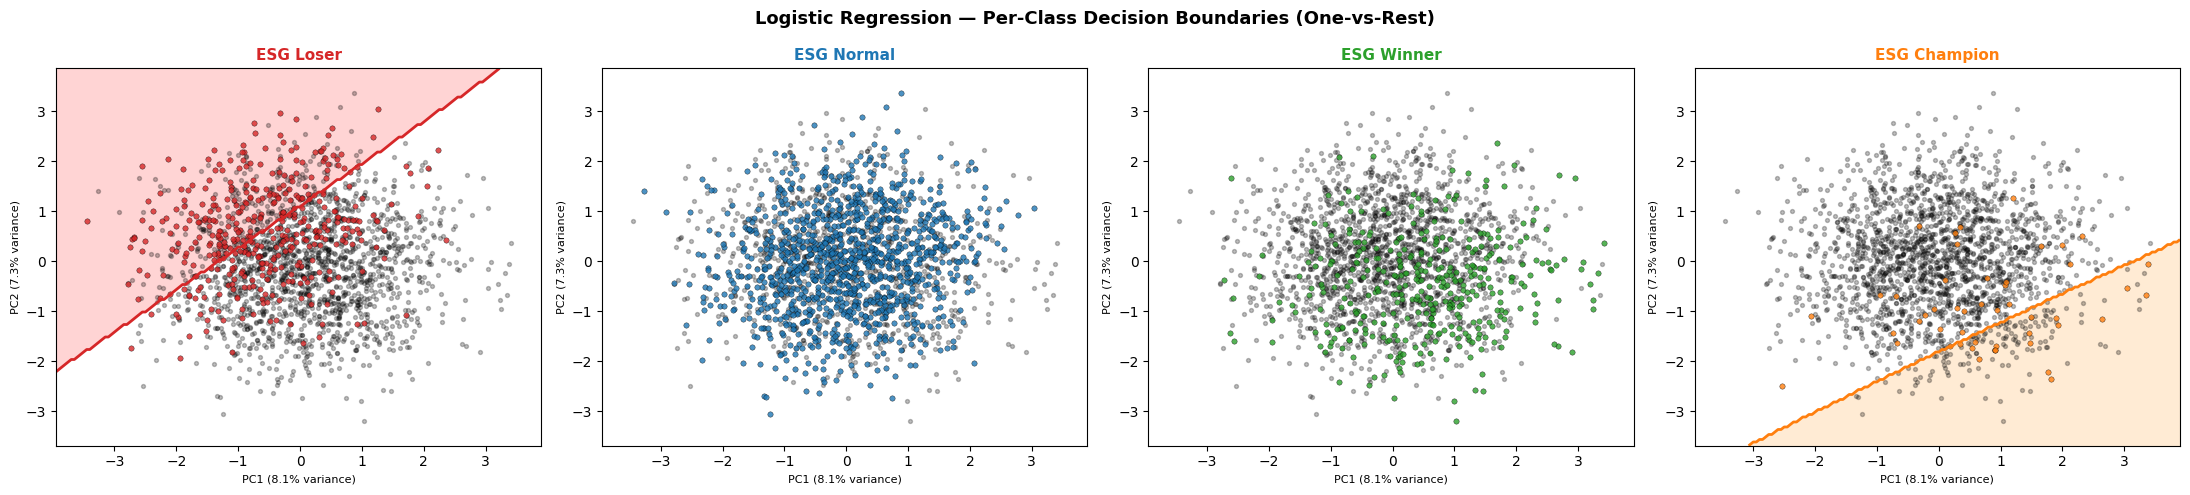

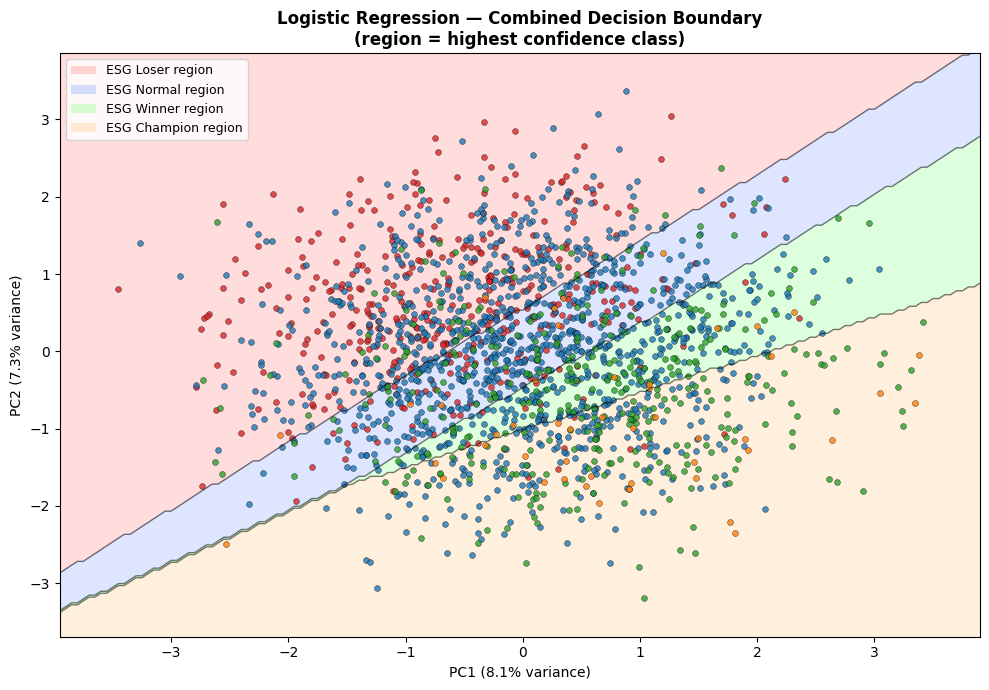

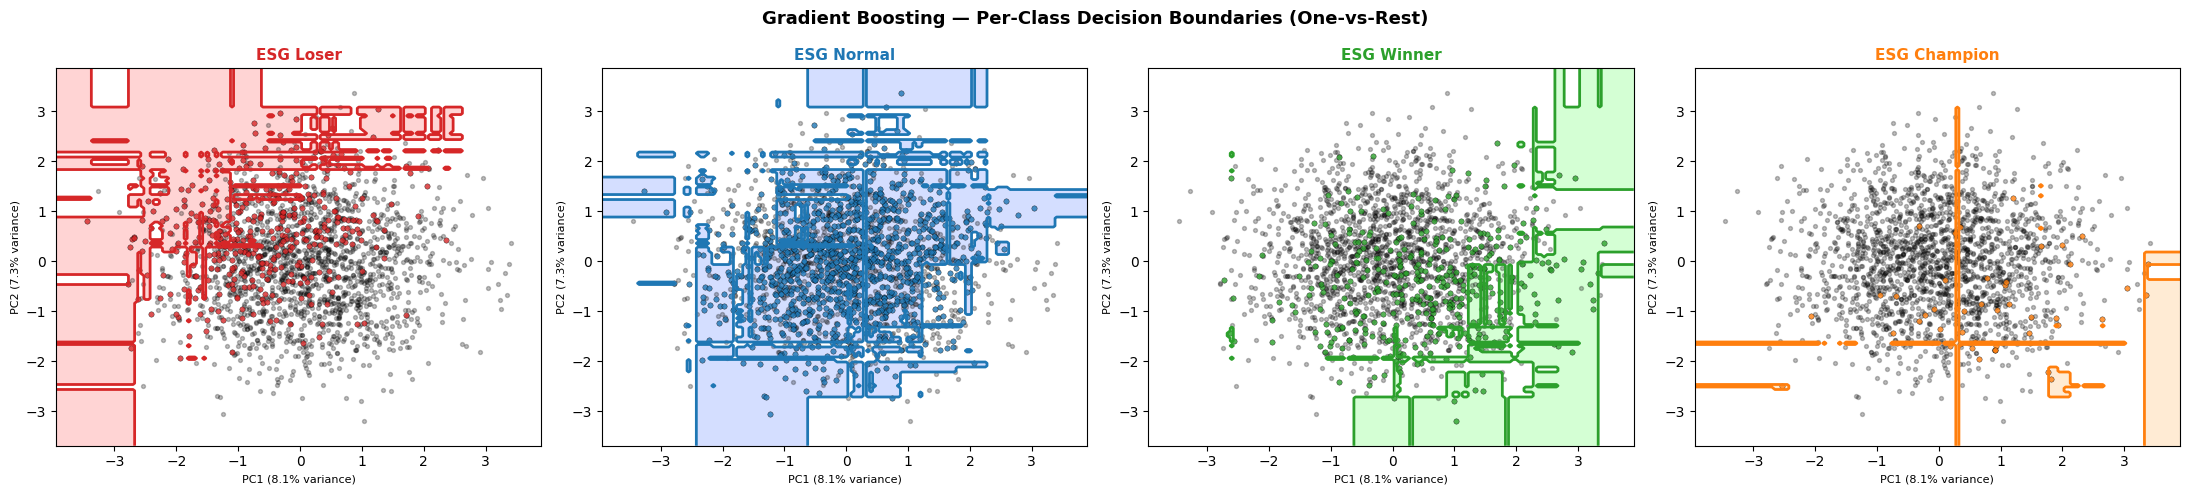

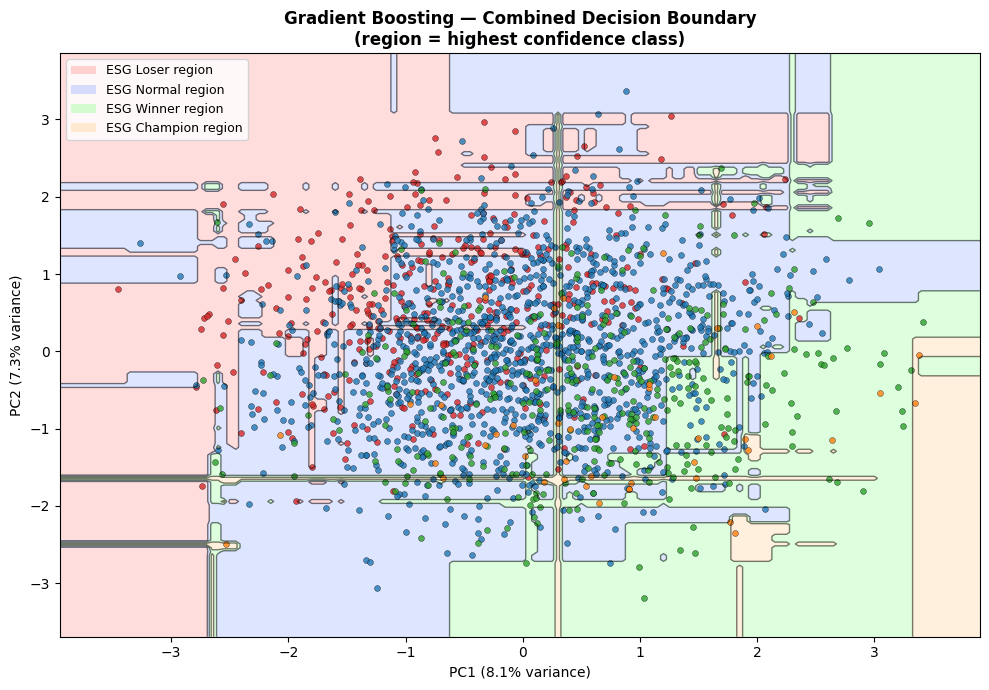

In [80]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Reduce to 2D via PCA ──
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_scal)
y_arr = np.array(y_train)

colors      = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e']
bg_colors   = ['#ffaaaa', '#aabfff', '#aaffaa', '#ffd9aa']
class_labels = ['ESG Loser', 'ESG Normal', 'ESG Winner', 'ESG Champion']

# ── 2. Refit both models on 2D data (for visualisation only) ──
log_2d = LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=2000)
log_2d.fit(X_2d, y_train)

gb_2d = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_2d.fit(X_2d, y_train)

# ── 3. Build mesh grid ──
h = 0.05
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
grid = np.c_[xx.ravel(), yy.ravel()]

pc1_label = f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)'
pc2_label = f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)'

# ══════════════════════════════════════════════════════════════
# PLOT A — Per-Class Boundaries (like lecture slide 19/22)
# One subplot per ESG class, shaded region = where P(class) > 50%
# ══════════════════════════════════════════════════════════════
def plot_per_class(model, model_name):
    proba = model.predict_proba(grid)   # shape: (n_mesh, 4)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f'{model_name} — Per-Class Decision Boundaries (One-vs-Rest)',
                 fontsize=13, fontweight='bold')

    for cls in range(4):
        ax = axes[cls]
        # Shade where this class > 50% probability
        Z = (proba[:, cls] > 0.5).reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=[0.5, 1.5],
                    colors=[bg_colors[cls]], alpha=0.5)
        ax.contour(xx, yy, Z, levels=[0.5],
                   colors=[colors[cls]], linewidths=2)

        # Other classes = black dots, this class = coloured dots
        other_mask = y_arr != cls
        this_mask  = y_arr == cls
        ax.scatter(X_2d[other_mask, 0], X_2d[other_mask, 1],
                   c='black', s=8, alpha=0.25)
        ax.scatter(X_2d[this_mask, 0], X_2d[this_mask, 1],
                   c=colors[cls], s=15, alpha=0.8,
                   edgecolors='k', linewidths=0.3)

        ax.set_title(class_labels[cls], fontsize=11, fontweight='bold',
                     color=colors[cls])
        ax.set_xlabel(pc1_label, fontsize=8)
        ax.set_ylabel(pc2_label, fontsize=8)

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════
# PLOT B — Combined Final Boundary (like lecture slide 23)
# Each region coloured by the most confident class
# ══════════════════════════════════════════════════════════════
def plot_combined(model, model_name):
    proba = model.predict_proba(grid)
    Z = np.argmax(proba, axis=1).reshape(xx.shape)

    cmap = ListedColormap(bg_colors)
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.4,
                levels=[-0.5, 0.5, 1.5, 2.5, 3.5])
    ax.contour(xx, yy, Z, colors='k', linewidths=1,
               alpha=0.5, levels=[0.5, 1.5, 2.5])

    for cls in range(4):
        mask = y_arr == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors[cls], label=class_labels[cls],
                   s=18, edgecolors='k', linewidths=0.3, alpha=0.8)

    region_patches = [mpatches.Patch(facecolor=bg_colors[i], alpha=0.5,
                                     label=f'{class_labels[i]} region')
                      for i in range(4)]
    ax.legend(handles=region_patches, loc='upper left', fontsize=9)
    ax.set_xlabel(pc1_label)
    ax.set_ylabel(pc2_label)
    ax.set_title(f'{model_name} — Combined Decision Boundary\n'
                 f'(region = highest confidence class)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ── Run both plots for both models ──
plot_per_class(log_2d,  'Logistic Regression')
plot_combined(log_2d,   'Logistic Regression')

plot_per_class(gb_2d,   'Gradient Boosting')
plot_combined(gb_2d,    'Gradient Boosting')

#### Thank you ###